In [ ]:
!pip -q install openpyxl scikit-learn catboost

In [ ]:
import os
import copy
import pickle
import zipfile
import shutil
import random
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from google.colab import files

from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    balanced_accuracy_score,
    brier_score_loss,
    confusion_matrix,
    ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore")

try:
    from catboost import CatBoostClassifier
    HAS_CATBOOST = True
except Exception as e:
    HAS_CATBOOST = False
    print("CatBoost no disponible:", e)

In [ ]:
SEED = 42

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", device)

OUTPUT_ROOT = "GeoFormer_outputs_baseline_encoding_strategies"

if os.path.exists(OUTPUT_ROOT):
    shutil.rmtree(OUTPUT_ROOT)

os.makedirs(OUTPUT_ROOT, exist_ok=True)

print("Carpeta de salida:", OUTPUT_ROOT)

Dispositivo: cpu
Carpeta de salida: GeoFormer_outputs_baseline_encoding_strategies


In [ ]:
uploaded = files.upload()

excel_path = list(uploaded.keys())[0]
df = pd.read_excel(excel_path)

df.columns = df.columns.str.strip()

ID_COL = "fid"
TARGET_COL = "class"
CAT_COLS = ["UGS", "GMF", "CLC", "SLOPE"]

GROUP_COL = None

excluded_cols = [ID_COL, TARGET_COL] + CAT_COLS
if GROUP_COL is not None:
    excluded_cols.append(GROUP_COL)

NUM_COLS = [c for c in df.columns if c not in excluded_cols]

print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])
print("Variables categóricas:", CAT_COLS)
print("Variables continuas:", NUM_COLS)

df.head()

Saving DataPaul.xlsx to DataPaul (1).xlsx
Filas: 400
Columnas: 10
Variables categóricas: ['UGS', 'GMF', 'CLC', 'SLOPE']
Variables continuas: ['TRI', 'TWI', 'Curvature', 'Elevation']


,fid,UGS,GMF,CLC,SLOPE,TRI,TWI,Curvature,Elevation,class
0,1,Srccsb,Sgf,31122.0,6,7.158911,2.103482,0.0128,1554,1
1,2,Rbmca,Dmc,2311.0,5,3.605551,2.897750,0.0256,2164,1
2,3,Srccp,Vla,232.0,5,5.220153,3.082989,-0.0128,2317,1
3,4,Srccp,Vla,32222.0,5,3.535534,3.946606,0.0000,2336,1
4,5,Srccp,Vle,232.0,5,3.535534,2.845010,0.0000,2274,1


In [ ]:
df = df.copy()

df = df.dropna(subset=[TARGET_COL]).reset_index(drop=True)
df[TARGET_COL] = df[TARGET_COL].astype(int)

def clean_category_value(v):
    if pd.isna(v):
        return "__MISSING__"
    if isinstance(v, float) and v.is_integer():
        return str(int(v))
    return str(v).strip()

for col in CAT_COLS:
    df[col] = df[col].apply(clean_category_value).astype(str)

for col in NUM_COLS:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print("Distribución de la variable objetivo:")
display(df[TARGET_COL].value_counts().rename("conteo"))
display(df[TARGET_COL].value_counts(normalize=True).rename("proporcion"))

Distribución de la variable objetivo:


,conteo
class,
1,269
0,131


,proporcion
class,
1,0.6725
0,0.3275


In [ ]:
indices = np.arange(len(df))
y_all = df[TARGET_COL].values

VALIDATION_SIZE = 0.25

if GROUP_COL is not None and GROUP_COL in df.columns:
    print("Usando separación por grupos espaciales:", GROUP_COL)

    groups = df[GROUP_COL].values

    gss_val = GroupShuffleSplit(
        n_splits=1,
        test_size=VALIDATION_SIZE,
        random_state=SEED
    )

    train_idx, val_idx = next(
        gss_val.split(df, y_all, groups=groups)
    )

else:
    print("Usando separación estratificada aleatoria.")

    train_idx, val_idx = train_test_split(
        indices,
        test_size=VALIDATION_SIZE,
        random_state=SEED,
        stratify=y_all
    )

print("Train:", len(train_idx), f"({len(train_idx) / len(df):.1%})")
print("Validation:", len(val_idx), f"({len(val_idx) / len(df):.1%})")

print("\nDistribución train:")
display(df.iloc[train_idx][TARGET_COL].value_counts())

print("\nDistribución validation:")
display(df.iloc[val_idx][TARGET_COL].value_counts())

split_df = pd.DataFrame({
    ID_COL: df[ID_COL].values,
    TARGET_COL: df[TARGET_COL].values,
    "split": "unused"
})

split_df.loc[train_idx, "split"] = "train"
split_df.loc[val_idx, "split"] = "validation"

split_df.to_excel(
    os.path.join(OUTPUT_ROOT, "split_indices_baseline_experiment.xlsx"),
    index=False
)

Usando separación estratificada aleatoria.
Train: 300 (75.0%)
Validation: 100 (25.0%)

Distribución train:


,count
class,
1,202
0,98



Distribución validation:


,count
class,
1,67
0,33


In [ ]:
def safe_auc(y_true, y_prob):
    if len(np.unique(y_true)) < 2:
        return np.nan
    return roc_auc_score(y_true, y_prob)


def safe_average_precision(y_true, y_prob):
    if len(np.unique(y_true)) < 2:
        return np.nan
    return average_precision_score(y_true, y_prob)


def compute_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)

    return {
        "AUC": safe_auc(y_true, y_prob),
        "AUPRC": safe_average_precision(y_true, y_prob),
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "MCC": matthews_corrcoef(y_true, y_pred),
        "Balanced_Accuracy": balanced_accuracy_score(y_true, y_pred),
        "Brier": brier_score_loss(y_true, y_prob)
    }


def find_best_threshold(y_true, y_prob, metric="min_errors"):
    thresholds = np.linspace(0.01, 0.99, 99)

    best_threshold = 0.5
    best_score = -np.inf

    report = []

    for th in thresholds:
        y_pred = (y_prob >= th).astype(int)

        cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
        tn, fp, fn, tp = cm.ravel()
        total_errors = fp + fn

        if metric == "f1":
            score = f1_score(y_true, y_pred, zero_division=0)

        elif metric == "accuracy":
            score = accuracy_score(y_true, y_pred)

        elif metric == "balanced_accuracy":
            score = balanced_accuracy_score(y_true, y_pred)

        elif metric == "youden":
            sensitivity = tp / (tp + fn + 1e-12)
            specificity = tn / (tn + fp + 1e-12)
            score = sensitivity + specificity - 1

        elif metric == "min_errors":
            score = -total_errors + 1e-3 * balanced_accuracy_score(y_true, y_pred)

        else:
            raise ValueError("metric debe ser: f1, accuracy, balanced_accuracy, youden o min_errors")

        report.append({
            "threshold": th,
            "metric": metric,
            "score": score,
            "TN": tn,
            "FP": fp,
            "FN": fn,
            "TP": tp,
            "total_errors": total_errors
        })

        if score > best_score:
            best_score = score
            best_threshold = th

    return best_threshold, best_score, pd.DataFrame(report)


def save_current_figure(output_path_png, dpi=300):
    output_path_png = str(output_path_png)
    output_path_svg = output_path_png.replace(".png", ".svg")

    plt.savefig(output_path_png, dpi=dpi, bbox_inches="tight")
    plt.savefig(output_path_svg, format="svg", bbox_inches="tight")

    return output_path_png, output_path_svg


def count_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [ ]:
def make_onehot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def fit_numeric_preprocessor(train_frame):
    if len(NUM_COLS) > 0:
        imputer = SimpleImputer(strategy="median")
        scaler = StandardScaler()

        X_train_imp = imputer.fit_transform(train_frame[NUM_COLS])
        scaler.fit(X_train_imp)

        def transform_numeric(frame):
            X_imp = imputer.transform(frame[NUM_COLS])
            X_scaled = scaler.transform(X_imp)
            return X_scaled.astype(np.float64)

    else:
        imputer = None
        scaler = None

        def transform_numeric(frame):
            return np.zeros((len(frame), 0), dtype=np.float64)

    return imputer, scaler, transform_numeric


def encode_nominal(train_frame, val_frame):
    maps = {}

    for col in CAT_COLS:
        values = sorted(train_frame[col].unique())
        maps[col] = {value: i for i, value in enumerate(values)}

    def transform(frame):
        arr = np.zeros((len(frame), len(CAT_COLS)), dtype=np.float64)

        for j, col in enumerate(CAT_COLS):
            mapping = maps[col]
            arr[:, j] = frame[col].map(mapping).fillna(-1).values

        return arr

    return transform(train_frame), transform(val_frame), maps


def encode_frequency(train_frame, val_frame):
    maps = {}

    for col in CAT_COLS:
        freq = train_frame[col].value_counts(normalize=True)
        maps[col] = freq.to_dict()

    def transform(frame):
        arr = np.zeros((len(frame), len(CAT_COLS)), dtype=np.float64)

        for j, col in enumerate(CAT_COLS):
            mapping = maps[col]
            arr[:, j] = frame[col].map(mapping).fillna(0.0).values

        return arr

    return transform(train_frame), transform(val_frame), maps


def encode_target(train_frame, val_frame, smoothing=10):
    maps = {}
    global_mean = train_frame[TARGET_COL].mean()

    for col in CAT_COLS:
        stats = (
            train_frame
            .groupby(col)[TARGET_COL]
            .agg(["mean", "count"])
        )

        smooth_values = (
            (stats["count"] * stats["mean"] + smoothing * global_mean)
            / (stats["count"] + smoothing)
        )

        maps[col] = smooth_values.to_dict()

    def transform(frame):
        arr = np.zeros((len(frame), len(CAT_COLS)), dtype=np.float64)

        for j, col in enumerate(CAT_COLS):
            mapping = maps[col]
            arr[:, j] = frame[col].map(mapping).fillna(global_mean).values

        return arr

    return transform(train_frame), transform(val_frame), maps


def encode_onehot(train_frame, val_frame):
    encoder = make_onehot_encoder()

    X_train = encoder.fit_transform(train_frame[CAT_COLS])
    X_val = encoder.transform(val_frame[CAT_COLS])

    return X_train.astype(np.float64), X_val.astype(np.float64), encoder


def build_encoded_dataset(encoding_name):
    train_frame = df.iloc[train_idx].copy()
    val_frame = df.iloc[val_idx].copy()

    imputer, scaler, transform_numeric = fit_numeric_preprocessor(train_frame)

    X_num_train = transform_numeric(train_frame)
    X_num_val = transform_numeric(val_frame)

    if encoding_name == "nominal":
        X_cat_train, X_cat_val, encoder_object = encode_nominal(train_frame, val_frame)

    elif encoding_name == "one_hot":
        X_cat_train, X_cat_val, encoder_object = encode_onehot(train_frame, val_frame)

    elif encoding_name == "frequency":
        X_cat_train, X_cat_val, encoder_object = encode_frequency(train_frame, val_frame)

    elif encoding_name == "target":
        X_cat_train, X_cat_val, encoder_object = encode_target(train_frame, val_frame)

    else:
        raise ValueError("encoding_name debe ser: nominal, one_hot, frequency o target")

    X_train = np.hstack([X_cat_train, X_num_train])
    X_val = np.hstack([X_cat_val, X_num_val])

    preprocessing = {
        "encoding": encoding_name,
        "encoder_object": encoder_object,
        "imputer": imputer,
        "scaler": scaler,
        "cat_cols": CAT_COLS,
        "num_cols": NUM_COLS
    }

    return X_train, X_val, preprocessing

In [ ]:
def build_sklearn_model(model_name):
    if model_name == "MLP":
        model = Pipeline([
            ("scaler", StandardScaler()),
            ("clf", MLPClassifier(
                hidden_layer_sizes=(64, 32),
                activation="relu",
                solver="adam",
                alpha=1e-4,
                learning_rate_init=1e-3,
                max_iter=1000,
                early_stopping=True,
                validation_fraction=0.15,
                n_iter_no_change=30,
                random_state=SEED
            ))
        ])

    elif model_name == "Random Forest":
        model = RandomForestClassifier(
            n_estimators=500,
            max_depth=None,
            min_samples_leaf=1,
            class_weight="balanced",
            random_state=SEED,
            n_jobs=-1
        )

    else:
        raise ValueError("model_name debe ser: MLP o Random Forest")

    return model


def build_random_forest_dataset():
    """
    Dataset para Random Forest.

    Nota metodológica:
    Random Forest no necesita embeddings ni one-hot/frequency/target encoding como
    estrategia principal. Sin embargo, la implementación RandomForestClassifier de
    scikit-learn requiere una matriz numérica. Por eso las categorías se pasan a
    códigos enteros simples. Esta conversión es un requisito técnico de entrada,
    no una codificación experimental comparable con one-hot, frequency o target.
    """
    train_frame = df.iloc[train_idx].copy()
    val_frame = df.iloc[val_idx].copy()

    X_cat_train, X_cat_val, code_maps = encode_nominal(train_frame, val_frame)

    if len(NUM_COLS) > 0:
        imputer = SimpleImputer(strategy="median")
        X_num_train = imputer.fit_transform(train_frame[NUM_COLS]).astype(np.float64)
        X_num_val = imputer.transform(val_frame[NUM_COLS]).astype(np.float64)
    else:
        imputer = None
        X_num_train = np.zeros((len(train_frame), 0), dtype=np.float64)
        X_num_val = np.zeros((len(val_frame), 0), dtype=np.float64)

    X_train = np.hstack([X_cat_train, X_num_train])
    X_val = np.hstack([X_cat_val, X_num_val])

    preprocessing = {
        "encoding": "categorical_codes",
        "note": (
            "Códigos enteros simples usados solo porque scikit-learn requiere "
            "entrada numérica para RandomForestClassifier; no corresponde a "
            "one-hot, frequency ni target encoding."
        ),
        "code_maps": code_maps,
        "imputer": imputer,
        "cat_cols": CAT_COLS,
        "num_cols": NUM_COLS
    }

    return X_train, X_val, preprocessing


def get_probabilities(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]

    raise ValueError("El modelo no tiene predict_proba")


def evaluate_classical_model(model_name, encoding_name):
    print("=" * 80)
    print(f"Modelo: {model_name} | Tratamiento categórico: {encoding_name}")
    print("=" * 80)

    if model_name == "MLP":
        X_train, X_val, preprocessing = build_encoded_dataset(encoding_name)

    elif model_name == "Random Forest":
        if encoding_name != "categorical_codes":
            raise ValueError(
                "Random Forest se evalúa solo con categorical_codes en esta versión. "
                "No se compara contra one_hot, frequency ni target encoding."
            )
        X_train, X_val, preprocessing = build_random_forest_dataset()

    else:
        raise ValueError("Esta función solo evalúa MLP y Random Forest. CatBoost se evalúa en modo nativo en la sección siguiente.")

    y_train = df.iloc[train_idx][TARGET_COL].values
    y_val = df.iloc[val_idx][TARGET_COL].values

    model = build_sklearn_model(model_name)

    start_time = time.time()
    model.fit(X_train, y_train)
    train_time_seconds = time.time() - start_time

    train_prob = get_probabilities(model, X_train)
    val_prob = get_probabilities(model, X_val)

    best_threshold, best_score, threshold_report = find_best_threshold(
        y_val,
        val_prob,
        metric="min_errors"
    )

    train_metrics = compute_metrics(y_train, train_prob, threshold=best_threshold)
    val_metrics = compute_metrics(y_val, val_prob, threshold=best_threshold)

    val_pred = (val_prob >= best_threshold).astype(int)
    cm = confusion_matrix(y_val, val_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    output_dir = os.path.join(
        OUTPUT_ROOT,
        f"{model_name.replace(' ', '_')}_{encoding_name}"
    )

    os.makedirs(output_dir, exist_ok=True)

    threshold_report.to_excel(
        os.path.join(output_dir, "threshold_report.xlsx"),
        index=False
    )

    pred_df = df.iloc[val_idx][[ID_COL, TARGET_COL] + CAT_COLS].copy()
    pred_df["model"] = model_name
    pred_df["encoding"] = encoding_name
    pred_df["prob_susceptibilidad"] = val_prob
    pred_df["pred_class"] = val_pred

    pred_df.to_excel(
        os.path.join(output_dir, "validation_predictions.xlsx"),
        index=False
    )

    with open(os.path.join(output_dir, "preprocessing.pkl"), "wb") as f:
        pickle.dump(preprocessing, f)

    with open(os.path.join(output_dir, "model.pkl"), "wb") as f:
        pickle.dump(model, f)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["No landslide", "Landslide"]
    )

    disp.plot()
    plt.title(
        f"{model_name} + {encoding_name}\n"
        f"threshold={best_threshold:.2f}"
    )

    save_current_figure(
        os.path.join(output_dir, "confusion_matrix_validation.png"),
        dpi=300
    )

    plt.show()

    rows = []

    for split_name, metrics_dict in [
        ("Train", train_metrics),
        ("Validation", val_metrics)
    ]:
        row = {
            "model": model_name,
            "encoding": encoding_name,
            "split": split_name,
            "best_threshold": best_threshold,
            "train_time_seconds": train_time_seconds,
            "n_features": X_train.shape[1],
            "TN": tn if split_name == "Validation" else np.nan,
            "FP": fp if split_name == "Validation" else np.nan,
            "FN": fn if split_name == "Validation" else np.nan,
            "TP": tp if split_name == "Validation" else np.nan,
            "validation_errors": (fp + fn) if split_name == "Validation" else np.nan
        }

        row.update(metrics_dict)
        rows.append(row)

    return pd.DataFrame(rows)

Modelo: MLP | Tratamiento categórico: nominal


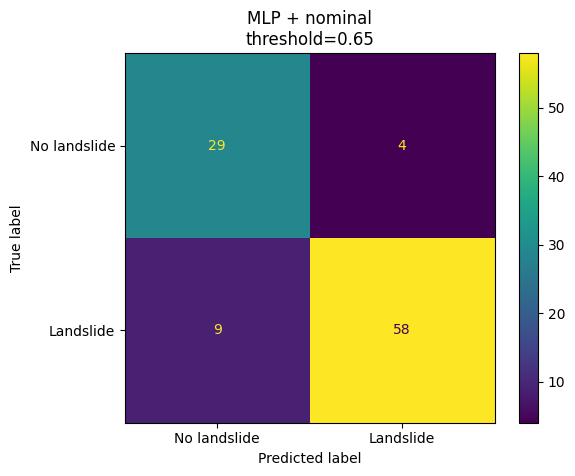

Modelo: MLP | Tratamiento categórico: one_hot


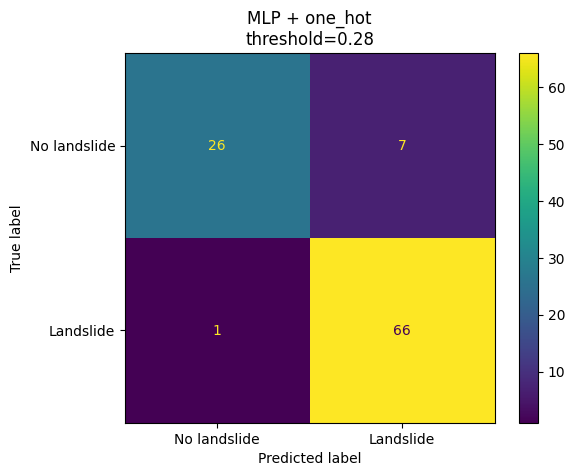

Modelo: MLP | Tratamiento categórico: frequency


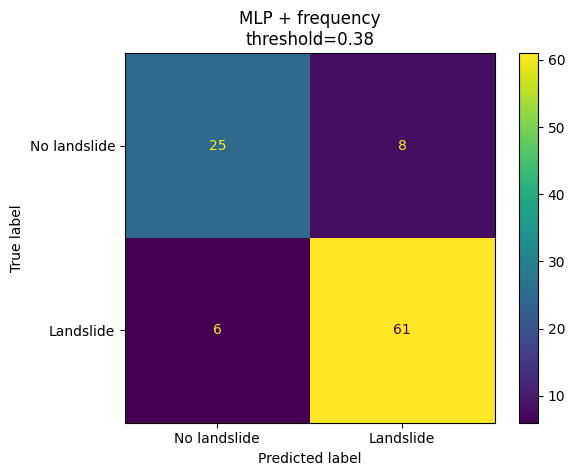

Modelo: MLP | Tratamiento categórico: target


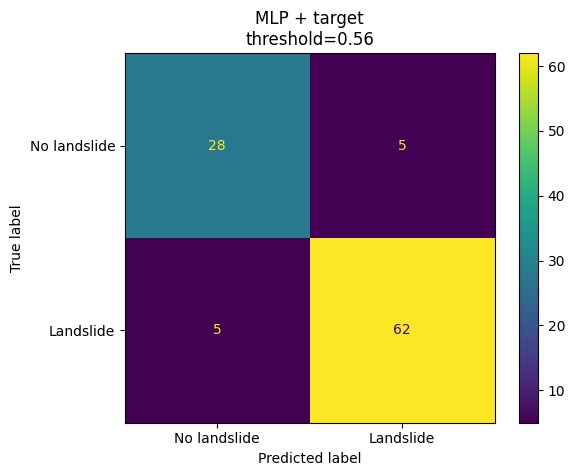

Modelo: Random Forest | Tratamiento categórico: categorical_codes


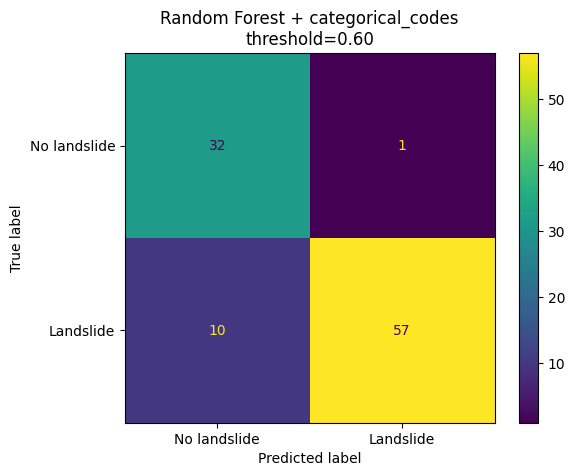

,model,encoding,split,best_threshold,train_time_seconds,n_features,TN,FP,FN,TP,validation_errors,AUC,AUPRC,Accuracy,Precision,Recall,F1,MCC,Balanced_Accuracy,Brier
3,MLP,one_hot,Validation,0.28,0.760304,106,26.0,7.0,1.0,66.0,8.0,0.964270,0.984696,0.92,0.904110,0.985075,0.942857,0.818662,0.886477,0.067904
7,MLP,target,Validation,0.56,0.440684,8,28.0,5.0,5.0,62.0,10.0,0.957033,0.981136,0.90,0.925373,0.925373,0.925373,0.773858,0.886929,0.079053
9,Random Forest,categorical_codes,Validation,0.60,2.916382,8,32.0,1.0,10.0,57.0,11.0,0.934419,0.971038,0.89,0.982759,0.850746,0.912000,0.781635,0.910222,0.097152
1,MLP,nominal,Validation,0.65,0.243274,8,29.0,4.0,9.0,58.0,13.0,0.925373,0.968070,0.87,0.935484,0.865672,0.899225,0.721187,0.872230,0.108803
5,MLP,frequency,Validation,0.38,0.393806,8,25.0,8.0,6.0,61.0,14.0,0.924469,0.965740,0.86,0.884058,0.910448,0.897059,0.679173,0.834012,0.107364


In [ ]:
MLP_ENCODINGS = ["nominal", "one_hot", "frequency", "target"]

classical_results = []

for encoding_name in MLP_ENCODINGS:
    result_df = evaluate_classical_model("MLP", encoding_name)
    classical_results.append(result_df)

rf_result_df = evaluate_classical_model("Random Forest", "categorical_codes")
classical_results.append(rf_result_df)

classical_metrics_df = pd.concat(classical_results, ignore_index=True)

classical_metrics_df.to_excel(
    os.path.join(OUTPUT_ROOT, "classical_models_all_metrics.xlsx"),
    index=False
)

display(
    classical_metrics_df
    .query("split == 'Validation'")
    .sort_values("AUC", ascending=False)
)

Entrenando CatBoost nativo con variables categóricas...


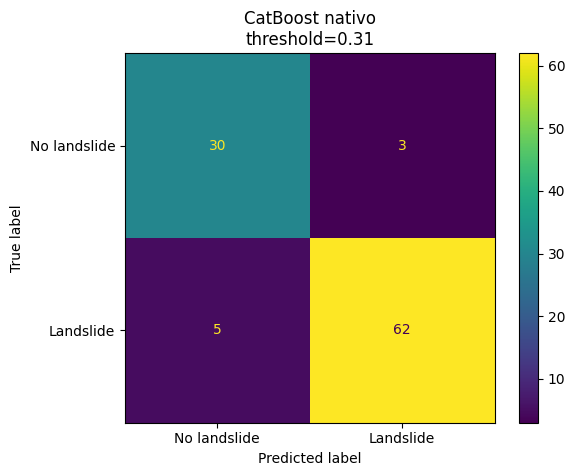

In [ ]:
catboost_native_metrics_df = pd.DataFrame()

if HAS_CATBOOST:
    print("Entrenando CatBoost nativo con variables categóricas...")

    train_frame = df.iloc[train_idx][CAT_COLS + NUM_COLS].copy()
    val_frame = df.iloc[val_idx][CAT_COLS + NUM_COLS].copy()

    for col in CAT_COLS:
        train_frame[col] = train_frame[col].astype(str)
        val_frame[col] = val_frame[col].astype(str)

    y_train = df.iloc[train_idx][TARGET_COL].values
    y_val = df.iloc[val_idx][TARGET_COL].values

    cat_features = list(range(len(CAT_COLS)))

    cat_model = CatBoostClassifier(
        iterations=500,
        depth=6,
        learning_rate=0.03,
        loss_function="Logloss",
        eval_metric="AUC",
        random_seed=SEED,
        verbose=False,
        auto_class_weights="Balanced",
        od_type="Iter",
        od_wait=50,
        allow_writing_files=False
    )

    start_time = time.time()

    cat_model.fit(
        train_frame,
        y_train,
        cat_features=cat_features,
        eval_set=(val_frame, y_val),
        use_best_model=True
    )

    train_time_seconds = time.time() - start_time

    train_prob = cat_model.predict_proba(train_frame)[:, 1]
    val_prob = cat_model.predict_proba(val_frame)[:, 1]

    best_threshold, best_score, threshold_report = find_best_threshold(
        y_val,
        val_prob,
        metric="min_errors"
    )

    train_metrics = compute_metrics(y_train, train_prob, threshold=best_threshold)
    val_metrics = compute_metrics(y_val, val_prob, threshold=best_threshold)

    val_pred = (val_prob >= best_threshold).astype(int)
    cm = confusion_matrix(y_val, val_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    output_dir = os.path.join(OUTPUT_ROOT, "CatBoost_native_categorical")
    os.makedirs(output_dir, exist_ok=True)

    threshold_report.to_excel(
        os.path.join(output_dir, "threshold_report.xlsx"),
        index=False
    )

    pred_df = df.iloc[val_idx][[ID_COL, TARGET_COL] + CAT_COLS].copy()
    pred_df["model"] = "CatBoost"
    pred_df["encoding"] = "native_categorical"
    pred_df["prob_susceptibilidad"] = val_prob
    pred_df["pred_class"] = val_pred

    pred_df.to_excel(
        os.path.join(output_dir, "validation_predictions.xlsx"),
        index=False
    )

    cat_model.save_model(os.path.join(output_dir, "catboost_native_model.cbm"))

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["No landslide", "Landslide"]
    )

    disp.plot()
    plt.title(f"CatBoost nativo\nthreshold={best_threshold:.2f}")
    save_current_figure(
        os.path.join(output_dir, "confusion_matrix_validation.png"),
        dpi=300
    )
    plt.show()

    rows = []

    for split_name, metrics_dict in [
        ("Train", train_metrics),
        ("Validation", val_metrics)
    ]:
        row = {
            "model": "CatBoost",
            "encoding": "native_categorical",
            "split": split_name,
            "best_threshold": best_threshold,
            "train_time_seconds": train_time_seconds,
            "n_features": train_frame.shape[1],
            "TN": tn if split_name == "Validation" else np.nan,
            "FP": fp if split_name == "Validation" else np.nan,
            "FN": fn if split_name == "Validation" else np.nan,
            "TP": tp if split_name == "Validation" else np.nan,
            "validation_errors": (fp + fn) if split_name == "Validation" else np.nan
        }

        row.update(metrics_dict)
        rows.append(row)

    catboost_native_metrics_df = pd.DataFrame(rows)

else:
    print("CatBoost no disponible. Se omite CatBoost nativo.")

In [ ]:
class GeoFormerDataset(Dataset):
    def __init__(self, X_cat, X_num, y):
        self.X_cat = torch.tensor(X_cat, dtype=torch.long)
        self.X_num = torch.tensor(X_num, dtype=torch.float64)
        self.y = torch.tensor(y, dtype=torch.float64)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X_cat[idx], self.X_num[idx], self.y[idx]

In [ ]:
class GeoFormerAttentionBlock(nn.Module):
    def __init__(
        self,
        d_model,
        n_heads,
        ff_dim,
        dropout
    ):
        super().__init__()

        self.self_attn = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=n_heads,
            dropout=dropout,
            batch_first=True
        )

        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

        self.dropout_attn = nn.Dropout(dropout)
        self.dropout_ffn = nn.Dropout(dropout)

        self.ffn = nn.Sequential(
            nn.Linear(d_model, ff_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(ff_dim, d_model)
        )

    def forward(self, x, return_attention=False):
        x_norm = self.norm1(x)

        attn_out, attn_weights = self.self_attn(
            x_norm,
            x_norm,
            x_norm,
            need_weights=return_attention,
            average_attn_weights=False
        )

        x = x + self.dropout_attn(attn_out)

        x_norm = self.norm2(x)
        x = x + self.dropout_ffn(self.ffn(x_norm))

        if return_attention:
            return x, attn_weights

        return x, None


class GeoFormer(nn.Module):
    def __init__(
        self,
        vocab_sizes,
        num_numeric,
        d_model=16,
        n_heads=2,
        n_layers=1,
        ff_dim=48,
        num_proj_dim=8,
        mlp_hidden=24,
        dropout=0.35,
        pooling="mean"
    ):
        super().__init__()

        assert d_model % n_heads == 0, "d_model debe ser divisible entre n_heads"
        assert pooling in ["mean", "cls"], "pooling debe ser 'mean' o 'cls'"

        self.vocab_sizes = vocab_sizes
        self.num_categorical = len(vocab_sizes)
        self.num_numeric = num_numeric
        self.d_model = d_model
        self.pooling = pooling

        self.embeddings = nn.ModuleList([
            nn.Embedding(vocab_size, d_model)
            for vocab_size in vocab_sizes
        ])

        self.factor_embedding = nn.Embedding(self.num_categorical, d_model)

        self.cat_input_norm = nn.LayerNorm(d_model)
        self.cat_dropout = nn.Dropout(dropout)

        if pooling == "cls":
            self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
        else:
            self.cls_token = None

        self.transformer_encoder = nn.ModuleList([
            GeoFormerAttentionBlock(
                d_model=d_model,
                n_heads=n_heads,
                ff_dim=ff_dim,
                dropout=dropout
            )
            for _ in range(n_layers)
        ])

        self.cat_output_norm = nn.LayerNorm(d_model)

        if num_numeric > 0:
            self.numeric_branch = nn.Sequential(
                nn.Linear(num_numeric, num_proj_dim),
                nn.LayerNorm(num_proj_dim),
                nn.GELU(),
                nn.Dropout(dropout)
            )
            fusion_dim = d_model + num_proj_dim
        else:
            self.numeric_branch = None
            fusion_dim = d_model

        self.prediction_head = nn.Sequential(
            nn.LayerNorm(fusion_dim),
            nn.Linear(fusion_dim, mlp_hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_hidden, max(mlp_hidden // 2, 4)),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(max(mlp_hidden // 2, 4), 1)
        )

        self._reset_parameters()

    def _reset_parameters(self):
        for emb in self.embeddings:
            nn.init.normal_(emb.weight, mean=0.0, std=0.02)

        nn.init.normal_(self.factor_embedding.weight, mean=0.0, std=0.02)

        if self.cls_token is not None:
            nn.init.normal_(self.cls_token, mean=0.0, std=0.02)

        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)

    def forward(self, x_cat, x_num, return_attention=False):
        batch_size = x_cat.size(0)

        token_list = []
        for j, emb in enumerate(self.embeddings):
            token_j = emb(x_cat[:, j])
            token_list.append(token_j)

        z = torch.stack(token_list, dim=1)

        factor_ids = torch.arange(
            self.num_categorical,
            device=x_cat.device
        ).unsqueeze(0).expand(batch_size, -1)

        z = z + self.factor_embedding(factor_ids)
        z = self.cat_input_norm(z)
        z = self.cat_dropout(z)

        if self.pooling == "cls":
            cls = self.cls_token.expand(batch_size, -1, -1)
            z = torch.cat([cls, z], dim=1)

        attention_layers = []

        for encoder_block in self.transformer_encoder:
            z, attn_weights = encoder_block(
                z,
                return_attention=return_attention
            )

            if return_attention:
                attention_layers.append(attn_weights)

        z = self.cat_output_norm(z)

        if self.pooling == "mean":
            h_cat = z.mean(dim=1)
        else:
            h_cat = z[:, 0, :]

        if self.numeric_branch is not None:
            h_num = self.numeric_branch(x_num)
            h = torch.cat([h_cat, h_num], dim=1)
        else:
            h = h_cat

        logits = self.prediction_head(h).squeeze(1)

        if return_attention:
            attention = torch.stack(attention_layers, dim=0)
            return logits, attention

        return logits

In [ ]:
GEOFORMER_HYPERPARAMS = {
    "d_model": 16,
    "n_heads": 2,
    "n_layers": 1,
    "ff_dim": 56,
    "num_proj_dim": 12,
    "mlp_hidden": 28,
    "dropout": 0.34,
    "pooling": "mean",

    "lr": 2.5e-4,
    "weight_decay": 5e-3,

    "epochs": 150,
    "patience": 10,
    "min_delta": 1e-4,
    "batch_size": 32,
    "max_grad_norm": 1.5
}

GEOFORMER_HYPERPARAMS

{'d_model': 16,
 'n_heads': 2,
 'n_layers': 1,
 'ff_dim': 56,
 'num_proj_dim': 12,
 'mlp_hidden': 28,
 'dropout': 0.34,
 'pooling': 'mean',
 'lr': 0.00025,
 'weight_decay': 0.005,
 'epochs': 150,
 'patience': 10,
 'min_delta': 0.0001,
 'batch_size': 32,
 'max_grad_norm': 1.5}

In [ ]:
def prepare_geoformer_data():
    cat_maps = {}

    for col in CAT_COLS:
        train_values = sorted(df.iloc[train_idx][col].unique())

        mapping = {"__UNK__": 0}

        for i, value in enumerate(train_values, start=1):
            mapping[value] = i

        cat_maps[col] = mapping

    vocab_sizes = [len(cat_maps[col]) for col in CAT_COLS]

    def encode_categorical(frame):
        arr = np.zeros((len(frame), len(CAT_COLS)), dtype=np.int64)

        for j, col in enumerate(CAT_COLS):
            mapping = cat_maps[col]
            arr[:, j] = frame[col].apply(lambda v: mapping.get(v, 0)).values

        return arr

    if len(NUM_COLS) > 0:
        imputer = SimpleImputer(strategy="median")
        scaler = StandardScaler()

        X_num_train_raw = df.iloc[train_idx][NUM_COLS]
        X_num_train_imp = imputer.fit_transform(X_num_train_raw)
        scaler.fit(X_num_train_imp)

        def transform_numeric(frame):
            x_imp = imputer.transform(frame[NUM_COLS])
            x_scaled = scaler.transform(x_imp)
            return x_scaled.astype(np.float64)

    else:
        imputer = None
        scaler = None

        def transform_numeric(frame):
            return np.zeros((len(frame), 0), dtype=np.float64)

    X_cat = encode_categorical(df)
    X_num = transform_numeric(df)
    y = df[TARGET_COL].values.astype(np.float64)

    return {
        "cat_maps": cat_maps,
        "vocab_sizes": vocab_sizes,
        "imputer": imputer,
        "scaler": scaler,
        "X_cat_train": X_cat[train_idx],
        "X_num_train": X_num[train_idx],
        "y_train": y[train_idx],
        "X_cat_val": X_cat[val_idx],
        "X_num_val": X_num[val_idx],
        "y_val": y[val_idx]
    }


def evaluate_geoformer_loader(model, loader, criterion):
    model.eval()

    all_y = []
    all_probs = []
    losses = []

    with torch.no_grad():
        for x_cat_batch, x_num_batch, y_batch in loader:
            x_cat_batch = x_cat_batch.to(device)
            x_num_batch = x_num_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(x_cat_batch, x_num_batch)
            loss = criterion(logits, y_batch)

            probs = torch.sigmoid(logits)

            losses.append(loss.item() * len(y_batch))
            all_y.append(y_batch.detach().cpu().numpy())
            all_probs.append(probs.detach().cpu().numpy())

    all_y = np.concatenate(all_y)
    all_probs = np.concatenate(all_probs)

    mean_loss = np.sum(losses) / len(all_y)

    return mean_loss, all_y, all_probs


def train_geoformer_one_epoch(model, loader, criterion, optimizer):
    model.train()

    losses = []

    for x_cat_batch, x_num_batch, y_batch in loader:
        x_cat_batch = x_cat_batch.to(device)
        x_num_batch = x_num_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        logits = model(x_cat_batch, x_num_batch)
        loss = criterion(logits, y_batch)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=GEOFORMER_HYPERPARAMS["max_grad_norm"]
        )

        optimizer.step()

        losses.append(loss.item() * len(y_batch))

    return np.sum(losses) / len(loader.dataset)

GeoFormer | epoch 001 | train_loss=0.5262 | val_loss=0.4717 | val_auc=0.3831 | lr=2.50e-04
GeoFormer | epoch 010 | train_loss=0.3798 | val_loss=0.3090 | val_auc=0.9272 | lr=2.50e-04
GeoFormer | epoch 020 | train_loss=0.2560 | val_loss=0.1709 | val_auc=0.9643 | lr=2.50e-04
GeoFormer | epoch 030 | train_loss=0.1411 | val_loss=0.1428 | val_auc=0.9661 | lr=2.50e-04
GeoFormer | Early stopping en epoch 39


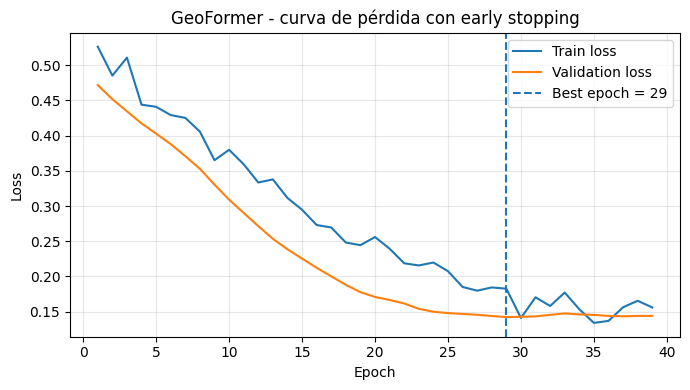

,model,early_stopping,best_epoch,best_val_loss,epochs_executed,patience,min_delta
0,GeoFormer,True,29,0.142338,39,10,0.0001


In [ ]:
set_seed(SEED)

geo_data = prepare_geoformer_data()

train_ds = GeoFormerDataset(
    geo_data["X_cat_train"],
    geo_data["X_num_train"],
    geo_data["y_train"]
)

val_ds = GeoFormerDataset(
    geo_data["X_cat_val"],
    geo_data["X_num_val"],
    geo_data["y_val"]
)

train_loader = DataLoader(
    train_ds,
    batch_size=GEOFORMER_HYPERPARAMS["batch_size"],
    shuffle=True,
    drop_last=False
)

val_loader = DataLoader(
    val_ds,
    batch_size=GEOFORMER_HYPERPARAMS["batch_size"],
    shuffle=False
)

geo_model = GeoFormer(
    vocab_sizes=geo_data["vocab_sizes"],
    num_numeric=geo_data["X_num_train"].shape[1],
    d_model=GEOFORMER_HYPERPARAMS["d_model"],
    n_heads=GEOFORMER_HYPERPARAMS["n_heads"],
    n_layers=GEOFORMER_HYPERPARAMS["n_layers"],
    ff_dim=GEOFORMER_HYPERPARAMS["ff_dim"],
    num_proj_dim=GEOFORMER_HYPERPARAMS["num_proj_dim"],
    mlp_hidden=GEOFORMER_HYPERPARAMS["mlp_hidden"],
    dropout=GEOFORMER_HYPERPARAMS["dropout"],
    pooling=GEOFORMER_HYPERPARAMS["pooling"]
).to(device).double()

n_pos = np.sum(geo_data["y_train"] == 1)
n_neg = np.sum(geo_data["y_train"] == 0)
pos_weight_value = n_neg / max(n_pos, 1)

criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor(
        [pos_weight_value],
        dtype=torch.float64,
        device=device
    )
)

optimizer = torch.optim.AdamW(
    geo_model.parameters(),
    lr=GEOFORMER_HYPERPARAMS["lr"],
    weight_decay=GEOFORMER_HYPERPARAMS["weight_decay"]
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3,
    min_lr=1e-6
)

best_val_loss = np.inf
best_epoch = 0
best_state = None
patience_counter = 0

history = []
start_time = time.time()

for epoch in range(1, GEOFORMER_HYPERPARAMS["epochs"] + 1):
    train_loss = train_geoformer_one_epoch(
        geo_model,
        train_loader,
        criterion,
        optimizer
    )

    val_loss, val_y_eval, val_probs = evaluate_geoformer_loader(
        geo_model,
        val_loader,
        criterion
    )

    scheduler.step(val_loss)

    val_auc = safe_auc(val_y_eval, val_probs)
    current_lr = optimizer.param_groups[0]["lr"]

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "val_auc": val_auc,
        "lr": current_lr,
        "best_epoch": best_epoch
    })

    improved = val_loss < best_val_loss - GEOFORMER_HYPERPARAMS["min_delta"]

    if improved:
        best_val_loss = val_loss
        best_epoch = epoch
        best_state = copy.deepcopy(geo_model.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1

    if epoch == 1 or epoch % 10 == 0:
        print(
            f"GeoFormer | epoch {epoch:03d} | "
            f"train_loss={train_loss:.4f} | "
            f"val_loss={val_loss:.4f} | "
            f"val_auc={val_auc:.4f} | "
            f"lr={current_lr:.2e}"
        )

    if patience_counter >= GEOFORMER_HYPERPARAMS["patience"]:
        print(f"GeoFormer | Early stopping en epoch {epoch}")
        break

geoformer_train_time_seconds = time.time() - start_time

geo_model.load_state_dict(best_state)

geoformer_history_df = pd.DataFrame(history)

geoformer_dir = os.path.join(OUTPUT_ROOT, "GeoFormer_task_driven_embeddings")
os.makedirs(geoformer_dir, exist_ok=True)

geoformer_history_df.to_csv(
    os.path.join(geoformer_dir, "training_history.csv"),
    index=False
)

early_stopping_summary_df = pd.DataFrame([{
    "model": "GeoFormer",
    "early_stopping": True,
    "best_epoch": best_epoch,
    "best_val_loss": best_val_loss,
    "epochs_executed": int(geoformer_history_df["epoch"].max()),
    "patience": GEOFORMER_HYPERPARAMS["patience"],
    "min_delta": GEOFORMER_HYPERPARAMS["min_delta"]
}])

early_stopping_summary_df.to_excel(
    os.path.join(geoformer_dir, "early_stopping_summary.xlsx"),
    index=False
)

plt.figure(figsize=(7, 4))
plt.plot(geoformer_history_df["epoch"], geoformer_history_df["train_loss"], label="Train loss")
plt.plot(geoformer_history_df["epoch"], geoformer_history_df["val_loss"], label="Validation loss")
plt.axvline(best_epoch, linestyle="--", label=f"Best epoch = {best_epoch}")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GeoFormer - curva de pérdida con early stopping")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

save_current_figure(
    os.path.join(geoformer_dir, "loss_curve.png"),
    dpi=300
)

plt.show()

display(early_stopping_summary_df)

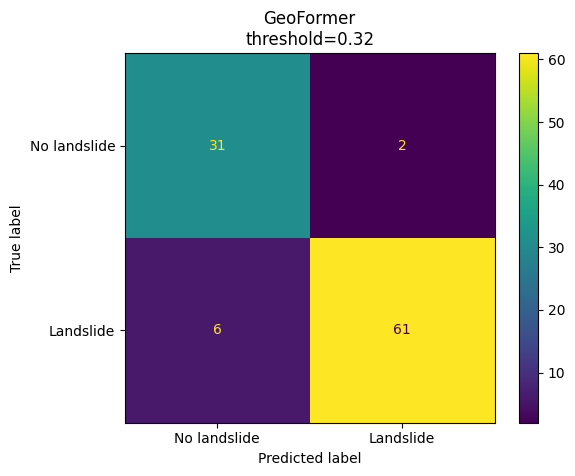

,model,encoding,split,best_threshold,train_time_seconds,n_features,TN,FP,FN,TP,...,epochs_executed,AUC,AUPRC,Accuracy,Precision,Recall,F1,MCC,Balanced_Accuracy,Brier
0,GeoFormer,task_driven_embeddings,Train,0.32,9.994652,8,NaN,NaN,NaN,NaN,...,39,0.990352,0.995826,0.956667,0.974874,0.960396,0.967581,0.902495,0.954688,0.038817
1,GeoFormer,task_driven_embeddings,Validation,0.32,9.994652,8,31.0,2.0,6.0,61.0,...,39,0.966983,0.986078,0.920000,0.968254,0.910448,0.938462,0.827678,0.924921,0.069586


In [ ]:
train_loss, train_y_eval, train_probs = evaluate_geoformer_loader(
    geo_model,
    train_loader,
    criterion
)

val_loss, val_y_eval, val_probs = evaluate_geoformer_loader(
    geo_model,
    val_loader,
    criterion
)

best_threshold, best_score, threshold_report = find_best_threshold(
    val_y_eval,
    val_probs,
    metric="min_errors"
)

train_metrics = compute_metrics(
    train_y_eval,
    train_probs,
    threshold=best_threshold
)

val_metrics = compute_metrics(
    val_y_eval,
    val_probs,
    threshold=best_threshold
)

val_pred = (val_probs >= best_threshold).astype(int)
cm = confusion_matrix(val_y_eval, val_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()

threshold_report.to_excel(
    os.path.join(geoformer_dir, "threshold_report.xlsx"),
    index=False
)

pred_df = df.iloc[val_idx][[ID_COL, TARGET_COL] + CAT_COLS].copy()
pred_df["model"] = "GeoFormer"
pred_df["encoding"] = "task_driven_embeddings"
pred_df["prob_susceptibilidad"] = val_probs
pred_df["pred_class"] = val_pred

pred_df.to_excel(
    os.path.join(geoformer_dir, "validation_predictions.xlsx"),
    index=False
)

torch.save(
    {
        "model_state_dict": geo_model.state_dict(),
        "vocab_sizes": geo_data["vocab_sizes"],
        "cat_cols": CAT_COLS,
        "num_cols": NUM_COLS,
        "hyperparams": GEOFORMER_HYPERPARAMS,
        "best_threshold": best_threshold,
        "early_stopping": True,
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
        "epochs_executed": int(geoformer_history_df["epoch"].max())
    },
    os.path.join(geoformer_dir, "GeoFormer_model.pt")
)

with open(os.path.join(geoformer_dir, "GeoFormer_preprocessing.pkl"), "wb") as f:
    pickle.dump(
        {
            "cat_maps": geo_data["cat_maps"],
            "imputer": geo_data["imputer"],
            "scaler": geo_data["scaler"],
            "cat_cols": CAT_COLS,
            "num_cols": NUM_COLS
        },
        f
    )

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No landslide", "Landslide"]
)

disp.plot()
plt.title(f"GeoFormer\nthreshold={best_threshold:.2f}")
save_current_figure(
    os.path.join(geoformer_dir, "confusion_matrix_validation.png"),
    dpi=300
)
plt.show()

geoformer_rows = []

for split_name, metrics_dict, loss_value in [
    ("Train", train_metrics, train_loss),
    ("Validation", val_metrics, val_loss)
]:
    row = {
        "model": "GeoFormer",
        "encoding": "task_driven_embeddings",
        "split": split_name,
        "best_threshold": best_threshold,
        "train_time_seconds": geoformer_train_time_seconds,
        "n_features": len(CAT_COLS) + len(NUM_COLS),
        "TN": tn if split_name == "Validation" else np.nan,
        "FP": fp if split_name == "Validation" else np.nan,
        "FN": fn if split_name == "Validation" else np.nan,
        "TP": tp if split_name == "Validation" else np.nan,
        "validation_errors": (fp + fn) if split_name == "Validation" else np.nan,
        "n_trainable_parameters": count_trainable_parameters(geo_model),
        "early_stopping": True,
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
        "epochs_executed": int(geoformer_history_df["epoch"].max())
    }

    row.update(metrics_dict)
    geoformer_rows.append(row)

geoformer_metrics_df = pd.DataFrame(geoformer_rows)

display(geoformer_metrics_df)

In [ ]:
class TabTransformerBaseline(nn.Module):
    """
    Baseline tipo TabTransformer.

    - Cada variable categórica entra como token.
    - Los tokens categóricos pasan por bloques Transformer.
    - Las variables continuas entran por una rama MLP.
    - Se fusionan ambas representaciones para clasificación binaria.
    """
    def __init__(
        self,
        vocab_sizes,
        num_numeric,
        d_model=16,
        n_heads=2,
        n_layers=2,
        ff_dim=64,
        num_proj_dim=12,
        mlp_hidden=28,
        dropout=0.34
    ):
        super().__init__()

        self.num_categorical = len(vocab_sizes)
        self.num_numeric = num_numeric

        self.embeddings = nn.ModuleList([
            nn.Embedding(vocab_size, d_model)
            for vocab_size in vocab_sizes
        ])

        self.column_embedding = nn.Embedding(self.num_categorical, d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=ff_dim,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=n_layers
        )

        self.cat_norm = nn.LayerNorm(d_model)

        if num_numeric > 0:
            self.numeric_branch = nn.Sequential(
                nn.Linear(num_numeric, num_proj_dim),
                nn.LayerNorm(num_proj_dim),
                nn.GELU(),
                nn.Dropout(dropout)
            )
            fusion_dim = d_model + num_proj_dim
        else:
            self.numeric_branch = None
            fusion_dim = d_model

        self.head = nn.Sequential(
            nn.LayerNorm(fusion_dim),
            nn.Linear(fusion_dim, mlp_hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_hidden, 1)
        )

    def forward(self, x_cat, x_num):
        tokens = []

        for j, emb in enumerate(self.embeddings):
            tokens.append(emb(x_cat[:, j]))

        x = torch.stack(tokens, dim=1)

        positions = torch.arange(
            self.num_categorical,
            device=x_cat.device
        ).unsqueeze(0)

        x = x + self.column_embedding(positions)
        x = self.transformer(x)

        h_cat = self.cat_norm(x.mean(dim=1))

        if self.numeric_branch is not None:
            h_num = self.numeric_branch(x_num)
            h = torch.cat([h_cat, h_num], dim=1)
        else:
            h = h_cat

        return self.head(h).squeeze(-1)


class FTTransformerBaseline(nn.Module):
    """
    Baseline tipo FT-Transformer.

    - Cada variable categórica y continua se convierte en token.
    - Se añade un token CLS.
    - El Transformer procesa todos los tokens.
    - La predicción se hace desde el token CLS.
    """
    def __init__(
        self,
        vocab_sizes,
        num_numeric,
        d_model=16,
        n_heads=2,
        n_layers=2,
        ff_dim=64,
        mlp_hidden=28,
        dropout=0.34
    ):
        super().__init__()

        self.num_categorical = len(vocab_sizes)
        self.num_numeric = num_numeric
        self.num_tokens = self.num_categorical + self.num_numeric

        self.cat_embeddings = nn.ModuleList([
            nn.Embedding(vocab_size, d_model)
            for vocab_size in vocab_sizes
        ])

        if num_numeric > 0:
            self.num_weight = nn.Parameter(
                torch.randn(num_numeric, d_model) * 0.02
            )
            self.num_bias = nn.Parameter(
                torch.zeros(num_numeric, d_model)
            )
        else:
            self.num_weight = None
            self.num_bias = None

        self.feature_embedding = nn.Embedding(self.num_tokens, d_model)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=ff_dim,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=n_layers
        )

        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, mlp_hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_hidden, 1)
        )

    def forward(self, x_cat, x_num):
        cat_tokens = []

        for j, emb in enumerate(self.cat_embeddings):
            cat_tokens.append(emb(x_cat[:, j]))

        tokens = torch.stack(cat_tokens, dim=1)

        if self.num_numeric > 0:
            num_tokens = (
                x_num.unsqueeze(-1) * self.num_weight.unsqueeze(0)
                + self.num_bias.unsqueeze(0)
            )
            tokens = torch.cat([tokens, num_tokens], dim=1)

        feature_ids = torch.arange(
            self.num_tokens,
            device=x_cat.device
        ).unsqueeze(0)

        tokens = tokens + self.feature_embedding(feature_ids)

        cls = self.cls_token.expand(tokens.shape[0], -1, -1)
        tokens = torch.cat([cls, tokens], dim=1)

        z = self.transformer(tokens)
        h_cls = z[:, 0, :]

        return self.head(h_cls).squeeze(-1)


class SAINTBlock(nn.Module):
    """
    Bloque SAINT simplificado.

    Primero aplica atención por columnas, es decir, entre variables de una misma muestra.
    Luego aplica atención por filas dentro del batch, es decir, entre muestras para cada variable.
    """
    def __init__(self, d_model, n_heads, ff_dim, dropout):
        super().__init__()

        self.norm_col = nn.LayerNorm(d_model)
        self.col_attn = nn.MultiheadAttention(
            d_model,
            n_heads,
            dropout=dropout,
            batch_first=True
        )

        self.norm_row = nn.LayerNorm(d_model)
        self.row_attn = nn.MultiheadAttention(
            d_model,
            n_heads,
            dropout=dropout,
            batch_first=True
        )

        self.norm_ffn = nn.LayerNorm(d_model)

        self.ffn = nn.Sequential(
            nn.Linear(d_model, ff_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(ff_dim, d_model)
        )

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x_norm = self.norm_col(x)

        col_out, _ = self.col_attn(
            x_norm,
            x_norm,
            x_norm,
            need_weights=False
        )

        x = x + self.dropout(col_out)

        x_row = self.norm_row(x).transpose(0, 1)
        row_out, _ = self.row_attn(
            x_row,
            x_row,
            x_row,
            need_weights=False
        )

        x = x + self.dropout(row_out.transpose(0, 1))

        x = x + self.dropout(self.ffn(self.norm_ffn(x)))

        return x


class SAINTBaseline(nn.Module):
    """
    Baseline tipo SAINT.

    Usa tokens para variables categóricas y continuas.
    Después aplica bloques con atención por columnas y atención por filas.
    """
    def __init__(
        self,
        vocab_sizes,
        num_numeric,
        d_model=16,
        n_heads=2,
        n_layers=2,
        ff_dim=64,
        mlp_hidden=32,
        dropout=0.20
    ):
        super().__init__()

        self.num_categorical = len(vocab_sizes)
        self.num_numeric = num_numeric
        self.num_tokens = self.num_categorical + self.num_numeric

        self.cat_embeddings = nn.ModuleList([
            nn.Embedding(vocab_size, d_model)
            for vocab_size in vocab_sizes
        ])

        if num_numeric > 0:
            self.num_weight = nn.Parameter(
                torch.randn(num_numeric, d_model) * 0.02
            )
            self.num_bias = nn.Parameter(
                torch.zeros(num_numeric, d_model)
            )
        else:
            self.num_weight = None
            self.num_bias = None

        self.feature_embedding = nn.Embedding(self.num_tokens, d_model)

        self.blocks = nn.ModuleList([
            SAINTBlock(
                d_model=d_model,
                n_heads=n_heads,
                ff_dim=ff_dim,
                dropout=dropout
            )
            for _ in range(n_layers)
        ])

        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, mlp_hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_hidden, 1)
        )

    def forward(self, x_cat, x_num):
        cat_tokens = []

        for j, emb in enumerate(self.cat_embeddings):
            cat_tokens.append(emb(x_cat[:, j]))

        tokens = torch.stack(cat_tokens, dim=1)

        if self.num_numeric > 0:
            num_tokens = (
                x_num.unsqueeze(-1) * self.num_weight.unsqueeze(0)
                + self.num_bias.unsqueeze(0)
            )
            tokens = torch.cat([tokens, num_tokens], dim=1)

        feature_ids = torch.arange(
            self.num_tokens,
            device=x_cat.device
        ).unsqueeze(0)

        x = tokens + self.feature_embedding(feature_ids)

        for block in self.blocks:
            x = block(x)

        h = x.mean(dim=1)

        return self.head(h).squeeze(-1)

In [ ]:
DEEP_TABULAR_HYPERPARAMS = {
    "d_model": 16,
    "n_heads": 2,
    "n_layers": 2,
    "ff_dim": 64,
    "mlp_hidden": 32,
    "dropout": 0.20,
    "lr": 2.5e-4,
    "weight_decay": 5e-3,
    "epochs": 150,
    "patience": 10,
    "min_delta": 1e-4,
    "batch_size": 32,
    "max_grad_norm": 1.5
}

DEEP_TABULAR_HYPERPARAMS


def evaluate_deep_loader(model, loader, criterion):
    model.eval()

    all_y = []
    all_probs = []
    losses = []

    with torch.no_grad():
        for x_cat_batch, x_num_batch, y_batch in loader:
            x_cat_batch = x_cat_batch.to(device)
            x_num_batch = x_num_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(x_cat_batch, x_num_batch)
            loss = criterion(logits, y_batch)

            probs = torch.sigmoid(logits)

            losses.append(loss.item() * len(y_batch))
            all_y.append(y_batch.detach().cpu().numpy())
            all_probs.append(probs.detach().cpu().numpy())

    all_y = np.concatenate(all_y)
    all_probs = np.concatenate(all_probs)

    mean_loss = np.sum(losses) / len(all_y)

    return mean_loss, all_y, all_probs


def train_deep_one_epoch(model, loader, criterion, optimizer):
    model.train()

    losses = []

    for x_cat_batch, x_num_batch, y_batch in loader:
        x_cat_batch = x_cat_batch.to(device)
        x_num_batch = x_num_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        logits = model(x_cat_batch, x_num_batch)
        loss = criterion(logits, y_batch)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=DEEP_TABULAR_HYPERPARAMS["max_grad_norm"]
        )

        optimizer.step()

        losses.append(loss.item() * len(y_batch))

    return np.sum(losses) / len(loader.dataset)


def build_deep_tabular_model(model_name, geo_data):
    common_kwargs = {
        "vocab_sizes": geo_data["vocab_sizes"],
        "num_numeric": geo_data["X_num_train"].shape[1],
        "d_model": DEEP_TABULAR_HYPERPARAMS["d_model"],
        "n_heads": DEEP_TABULAR_HYPERPARAMS["n_heads"],
        "n_layers": DEEP_TABULAR_HYPERPARAMS["n_layers"],
        "ff_dim": DEEP_TABULAR_HYPERPARAMS["ff_dim"],
        "mlp_hidden": DEEP_TABULAR_HYPERPARAMS["mlp_hidden"],
        "dropout": DEEP_TABULAR_HYPERPARAMS["dropout"]
    }

    if model_name == "TabTransformer":
        model = TabTransformerBaseline(
            **common_kwargs,
            num_proj_dim=12
        )

    elif model_name == "FT-Transformer":
        model = FTTransformerBaseline(**common_kwargs)

    elif model_name == "SAINT":
        model = SAINTBaseline(**common_kwargs)

    else:
        raise ValueError("model_name debe ser: TabTransformer, FT-Transformer o SAINT")

    return model.to(device).double()


def train_and_evaluate_deep_tabular_model(model_name):
    print("=" * 80)
    print(f"Entrenando {model_name}")
    print("=" * 80)

    set_seed(SEED)

    train_ds = GeoFormerDataset(
        geo_data["X_cat_train"],
        geo_data["X_num_train"],
        geo_data["y_train"]
    )

    val_ds = GeoFormerDataset(
        geo_data["X_cat_val"],
        geo_data["X_num_val"],
        geo_data["y_val"]
    )

    train_loader = DataLoader(
        train_ds,
        batch_size=DEEP_TABULAR_HYPERPARAMS["batch_size"],
        shuffle=True,
        drop_last=False
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=DEEP_TABULAR_HYPERPARAMS["batch_size"],
        shuffle=False
    )

    model = build_deep_tabular_model(model_name, geo_data)

    n_pos = np.sum(geo_data["y_train"] == 1)
    n_neg = np.sum(geo_data["y_train"] == 0)
    pos_weight_value = n_neg / max(n_pos, 1)

    criterion = nn.BCEWithLogitsLoss(
        pos_weight=torch.tensor(
            [pos_weight_value],
            dtype=torch.float64,
            device=device
        )
    )

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=DEEP_TABULAR_HYPERPARAMS["lr"],
        weight_decay=DEEP_TABULAR_HYPERPARAMS["weight_decay"]
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=3,
        min_lr=1e-6
    )

    best_val_loss = np.inf
    best_epoch = 0
    best_state = None
    patience_counter = 0

    history = []
    start_time = time.time()

    for epoch in range(1, DEEP_TABULAR_HYPERPARAMS["epochs"] + 1):
        train_loss = train_deep_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer
        )

        val_loss, val_y_eval, val_probs = evaluate_deep_loader(
            model,
            val_loader,
            criterion
        )

        scheduler.step(val_loss)

        val_auc = safe_auc(val_y_eval, val_probs)
        current_lr = optimizer.param_groups[0]["lr"]

        history.append({
            "model": model_name,
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "val_auc": val_auc,
            "lr": current_lr
        })

        improved = val_loss < best_val_loss - DEEP_TABULAR_HYPERPARAMS["min_delta"]

        if improved:
            best_val_loss = val_loss
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        if epoch == 1 or epoch % 10 == 0:
            print(
                f"{model_name} | epoch {epoch:03d} | "
                f"train_loss={train_loss:.4f} | "
                f"val_loss={val_loss:.4f} | "
                f"val_auc={val_auc:.4f} | "
                f"lr={current_lr:.2e}"
            )

        if patience_counter >= DEEP_TABULAR_HYPERPARAMS["patience"]:
            print(f"{model_name} | Early stopping en epoch {epoch}")
            break

    train_time_seconds = time.time() - start_time

    model.load_state_dict(best_state)

    output_dir = os.path.join(
        OUTPUT_ROOT,
        f"{model_name.replace('-', '_').replace(' ', '_')}_deep_tabular"
    )

    os.makedirs(output_dir, exist_ok=True)

    history_df = pd.DataFrame(history)

    history_df.to_csv(
        os.path.join(output_dir, "training_history.csv"),
        index=False
    )

    early_stopping_summary_df = pd.DataFrame([{
        "model": model_name,
        "early_stopping": True,
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
        "epochs_executed": int(history_df["epoch"].max()),
        "patience": DEEP_TABULAR_HYPERPARAMS["patience"],
        "min_delta": DEEP_TABULAR_HYPERPARAMS["min_delta"]
    }])

    early_stopping_summary_df.to_excel(
        os.path.join(output_dir, "early_stopping_summary.xlsx"),
        index=False
    )

    plt.figure(figsize=(7, 4))
    plt.plot(history_df["epoch"], history_df["train_loss"], label="Train loss")
    plt.plot(history_df["epoch"], history_df["val_loss"], label="Validation loss")
    plt.axvline(best_epoch, linestyle="--", label=f"Best epoch = {best_epoch}")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{model_name} - curva de pérdida")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    save_current_figure(
        os.path.join(output_dir, "loss_curve.png"),
        dpi=300
    )

    plt.show()

    train_loss, train_y_eval, train_probs = evaluate_deep_loader(
        model,
        train_loader,
        criterion
    )

    val_loss, val_y_eval, val_probs = evaluate_deep_loader(
        model,
        val_loader,
        criterion
    )

    best_threshold, best_score, threshold_report = find_best_threshold(
        val_y_eval,
        val_probs,
        metric="min_errors"
    )

    train_metrics = compute_metrics(
        train_y_eval,
        train_probs,
        threshold=best_threshold
    )

    val_metrics = compute_metrics(
        val_y_eval,
        val_probs,
        threshold=best_threshold
    )

    val_pred = (val_probs >= best_threshold).astype(int)
    cm = confusion_matrix(val_y_eval, val_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    threshold_report.to_excel(
        os.path.join(output_dir, "threshold_report.xlsx"),
        index=False
    )

    pred_df = df.iloc[val_idx][[ID_COL, TARGET_COL] + CAT_COLS].copy()
    pred_df["model"] = model_name
    pred_df["encoding"] = "deep_tabular_embeddings"
    pred_df["prob_susceptibilidad"] = val_probs
    pred_df["pred_class"] = val_pred

    pred_df.to_excel(
        os.path.join(output_dir, "validation_predictions.xlsx"),
        index=False
    )

    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "vocab_sizes": geo_data["vocab_sizes"],
            "cat_cols": CAT_COLS,
            "num_cols": NUM_COLS,
            "hyperparams": DEEP_TABULAR_HYPERPARAMS,
            "model_name": model_name,
            "best_threshold": best_threshold,
            "best_epoch": best_epoch,
            "best_val_loss": best_val_loss
        },
        os.path.join(output_dir, f"{model_name.replace('-', '_')}_model.pt")
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["No landslide", "Landslide"]
    )

    disp.plot()
    plt.title(f"{model_name}\nthreshold={best_threshold:.2f}")
    save_current_figure(
        os.path.join(output_dir, "confusion_matrix_validation.png"),
        dpi=300
    )
    plt.show()

    rows = []

    for split_name, metrics_dict, loss_value in [
        ("Train", train_metrics, train_loss),
        ("Validation", val_metrics, val_loss)
    ]:
        row = {
            "model": model_name,
            "encoding": "deep_tabular_embeddings",
            "split": split_name,
            "best_threshold": best_threshold,
            "train_time_seconds": train_time_seconds,
            "n_features": len(CAT_COLS) + len(NUM_COLS),
            "TN": tn if split_name == "Validation" else np.nan,
            "FP": fp if split_name == "Validation" else np.nan,
            "FN": fn if split_name == "Validation" else np.nan,
            "TP": tp if split_name == "Validation" else np.nan,
            "validation_errors": (fp + fn) if split_name == "Validation" else np.nan,
            "n_trainable_parameters": count_trainable_parameters(model),
            "early_stopping": True,
            "best_epoch": best_epoch,
            "best_val_loss": best_val_loss,
            "epochs_executed": int(history_df["epoch"].max())
        }

        row.update(metrics_dict)
        rows.append(row)

    return pd.DataFrame(rows)

Entrenando TabTransformer
TabTransformer | epoch 001 | train_loss=0.4626 | val_loss=0.4637 | val_auc=0.3691 | lr=2.50e-04
TabTransformer | epoch 010 | train_loss=0.3846 | val_loss=0.3913 | val_auc=0.8924 | lr=2.50e-04
TabTransformer | epoch 020 | train_loss=0.2548 | val_loss=0.2586 | val_auc=0.9376 | lr=2.50e-04
TabTransformer | epoch 030 | train_loss=0.1416 | val_loss=0.1848 | val_auc=0.9507 | lr=2.50e-04
TabTransformer | epoch 040 | train_loss=0.1019 | val_loss=0.1785 | val_auc=0.9516 | lr=2.50e-04
TabTransformer | Early stopping en epoch 49


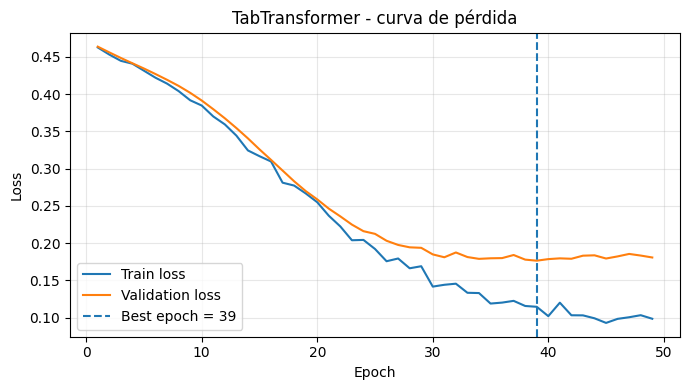

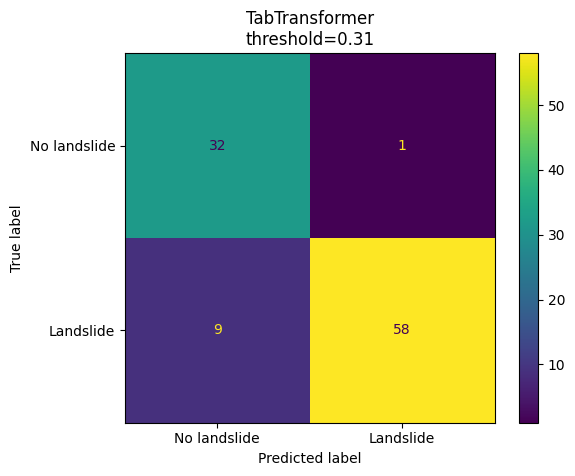

Entrenando FT-Transformer
FT-Transformer | epoch 001 | train_loss=0.4557 | val_loss=0.4522 | val_auc=0.6174 | lr=2.50e-04
FT-Transformer | epoch 010 | train_loss=0.3777 | val_loss=0.3322 | val_auc=0.9299 | lr=2.50e-04
FT-Transformer | epoch 020 | train_loss=0.2721 | val_loss=0.2583 | val_auc=0.9231 | lr=2.50e-04
FT-Transformer | epoch 030 | train_loss=0.2373 | val_loss=0.2367 | val_auc=0.9362 | lr=2.50e-04
FT-Transformer | epoch 040 | train_loss=0.2225 | val_loss=0.2320 | val_auc=0.9254 | lr=2.50e-04
FT-Transformer | Early stopping en epoch 48


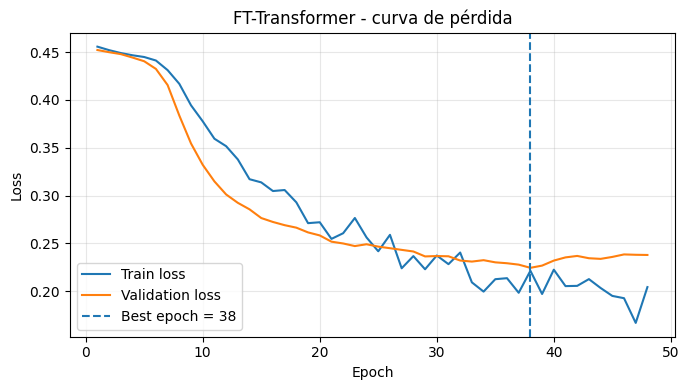

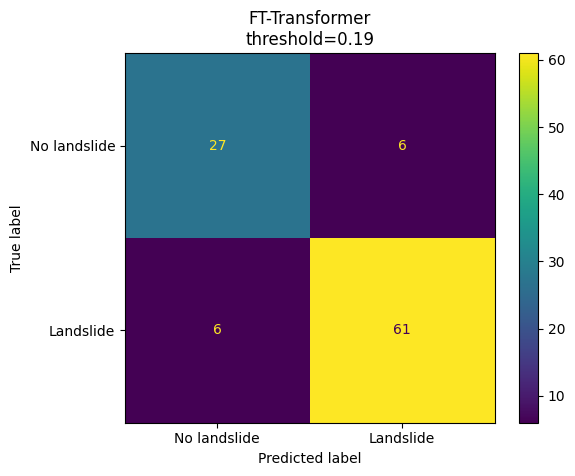

Entrenando SAINT
SAINT | epoch 001 | train_loss=0.4460 | val_loss=0.4415 | val_auc=0.7576 | lr=2.50e-04
SAINT | epoch 010 | train_loss=0.3390 | val_loss=0.3362 | val_auc=0.9195 | lr=2.50e-04
SAINT | epoch 020 | train_loss=0.2052 | val_loss=0.2176 | val_auc=0.9290 | lr=2.50e-04
SAINT | epoch 030 | train_loss=0.1420 | val_loss=0.1914 | val_auc=0.9389 | lr=2.50e-04
SAINT | epoch 040 | train_loss=0.1291 | val_loss=0.1908 | val_auc=0.9353 | lr=6.25e-05
SAINT | Early stopping en epoch 41


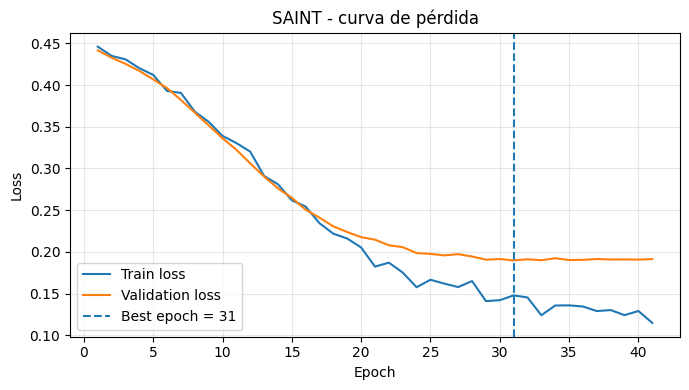

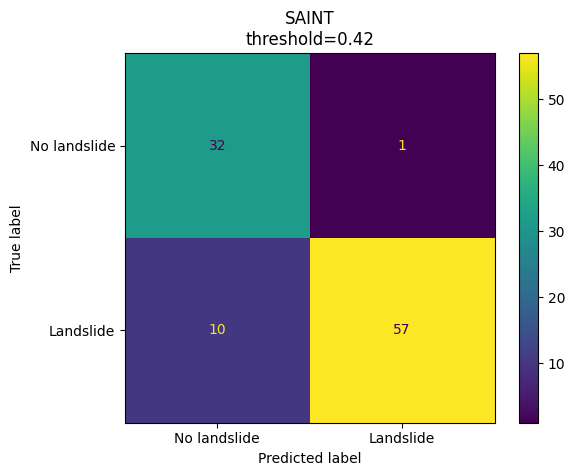

,model,encoding,split,best_threshold,train_time_seconds,n_features,TN,FP,FN,TP,...,epochs_executed,AUC,AUPRC,Accuracy,Precision,Recall,F1,MCC,Balanced_Accuracy,Brier
1,TabTransformer,deep_tabular_embeddings,Validation,0.31,12.529267,8,32.0,1.0,9.0,58.0,...,49,0.952058,0.979185,0.90,0.983051,0.865672,0.920635,0.798646,0.917684,0.096085
5,SAINT,deep_tabular_embeddings,Validation,0.42,8.077270,8,32.0,1.0,10.0,57.0,...,41,0.937585,0.973773,0.89,0.982759,0.850746,0.912000,0.781635,0.910222,0.099106
3,FT-Transformer,deep_tabular_embeddings,Validation,0.19,7.793515,8,27.0,6.0,6.0,61.0,...,48,0.924921,0.957392,0.88,0.910448,0.910448,0.910448,0.728630,0.864315,0.111784


In [ ]:
DEEP_TABULAR_MODELS = [
    "TabTransformer",
    "FT-Transformer",
    "SAINT"
]

deep_tabular_results = []

for model_name in DEEP_TABULAR_MODELS:
    result_df = train_and_evaluate_deep_tabular_model(model_name)
    deep_tabular_results.append(result_df)

deep_tabular_metrics_df = pd.concat(
    deep_tabular_results,
    ignore_index=True
)

deep_tabular_metrics_df.to_excel(
    os.path.join(OUTPUT_ROOT, "deep_tabular_models_all_metrics.xlsx"),
    index=False
)

display(
    deep_tabular_metrics_df
    .query("split == 'Validation'")
    .sort_values("AUC", ascending=False)
)

In [ ]:
metrics_parts = [classical_metrics_df]

if len(catboost_native_metrics_df) > 0:
    metrics_parts.append(catboost_native_metrics_df)

metrics_parts.append(geoformer_metrics_df)

if "deep_tabular_metrics_df" in globals() and len(deep_tabular_metrics_df) > 0:
    metrics_parts.append(deep_tabular_metrics_df)

all_metrics_df = pd.concat(metrics_parts, ignore_index=True)

all_metrics_df.to_excel(
    os.path.join(OUTPUT_ROOT, "all_metrics_baseline_encoding_strategies.xlsx"),
    index=False
)

validation_metrics_df = (
    all_metrics_df
    .query("split == 'Validation'")
    .copy()
    .sort_values(["AUC", "F1", "MCC"], ascending=False)
    .reset_index(drop=True)
)

validation_metrics_df.to_excel(
    os.path.join(OUTPUT_ROOT, "validation_metrics_baseline_encoding_strategies.xlsx"),
    index=False
)

ranking_df = validation_metrics_df.copy()
ranking_df["rank_AUC"] = ranking_df["AUC"].rank(ascending=False, method="min")
ranking_df["rank_F1"] = ranking_df["F1"].rank(ascending=False, method="min")
ranking_df["rank_MCC"] = ranking_df["MCC"].rank(ascending=False, method="min")
ranking_df["rank_Balanced_Accuracy"] = ranking_df["Balanced_Accuracy"].rank(ascending=False, method="min")

ranking_df.to_excel(
    os.path.join(OUTPUT_ROOT, "ranking_baseline_encoding_strategies.xlsx"),
    index=False
)

display(ranking_df)

,model,encoding,split,best_threshold,train_time_seconds,n_features,TN,FP,FN,TP,...,Brier,n_trainable_parameters,early_stopping,best_epoch,best_val_loss,epochs_executed,rank_AUC,rank_F1,rank_MCC,rank_Balanced_Accuracy
0,GeoFormer,task_driven_embeddings,Validation,0.32,9.994652,8,31.0,2.0,6.0,61.0,...,0.069586,6213.0,True,29.0,0.142338,39.0,1.0,3.0,1.0,1.0
1,MLP,one_hot,Validation,0.28,0.760304,106,26.0,7.0,1.0,66.0,...,0.067904,NaN,NaN,NaN,NaN,NaN,2.0,1.0,3.0,7.0
2,CatBoost,native_categorical,Validation,0.31,1.251746,8,30.0,3.0,5.0,62.0,...,0.081321,NaN,NaN,NaN,NaN,NaN,3.0,2.0,2.0,3.0
3,MLP,target,Validation,0.56,0.440684,8,28.0,5.0,5.0,62.0,...,0.079053,NaN,NaN,NaN,NaN,NaN,4.0,4.0,7.0,6.0
4,TabTransformer,deep_tabular_embeddings,Validation,0.31,12.529267,8,32.0,1.0,9.0,58.0,...,0.096085,9453.0,True,39.0,0.176365,49.0,5.0,5.0,4.0,2.0
5,SAINT,deep_tabular_embeddings,Validation,0.42,8.077270,8,32.0,1.0,10.0,57.0,...,0.099106,11361.0,True,31.0,0.189753,41.0,6.0,6.0,5.0,4.0
6,Random Forest,categorical_codes,Validation,0.60,2.916382,8,32.0,1.0,10.0,57.0,...,0.097152,NaN,NaN,NaN,NaN,NaN,7.0,6.0,5.0,4.0
7,MLP,nominal,Validation,0.65,0.243274,8,29.0,4.0,9.0,58.0,...,0.108803,NaN,NaN,NaN,NaN,NaN,8.0,9.0,9.0,8.0
8,FT-Transformer,deep_tabular_embeddings,Validation,0.19,7.793515,8,27.0,6.0,6.0,61.0,...,0.111784,9137.0,True,38.0,0.224439,48.0,9.0,8.0,8.0,9.0
9,MLP,frequency,Validation,0.38,0.393806,8,25.0,8.0,6.0,61.0,...,0.107364,NaN,NaN,NaN,NaN,NaN,10.0,10.0,10.0,10.0


,model,encoding,AUC,AUPRC,F1,MCC,Balanced_Accuracy,Brier,mean_rank
0,GeoFormer,task_driven_embeddings,0.966983,0.986078,0.938462,0.827678,0.924921,0.069586,1.500000
1,MLP,one_hot,0.964270,0.984696,0.942857,0.818662,0.886477,0.067904,2.666667
2,CatBoost,native_categorical,0.961782,0.983056,0.939394,0.822643,0.917232,0.081321,2.833333
3,TabTransformer,deep_tabular_embeddings,0.952058,0.979185,0.920635,0.798646,0.917684,0.096085,4.333333
4,MLP,target,0.957033,0.981136,0.925373,0.773858,0.886929,0.079053,4.666667
5,SAINT,deep_tabular_embeddings,0.937585,0.973773,0.912000,0.781635,0.910222,0.099106,5.666667
6,Random Forest,categorical_codes,0.934419,0.971038,0.912000,0.781635,0.910222,0.097152,5.833333
7,MLP,nominal,0.925373,0.968070,0.899225,0.721187,0.872230,0.108803,8.500000
8,FT-Transformer,deep_tabular_embeddings,0.924921,0.957392,0.910448,0.728630,0.864315,0.111784,9.000000
9,MLP,frequency,0.924469,0.965740,0.897059,0.679173,0.834012,0.107364,9.500000


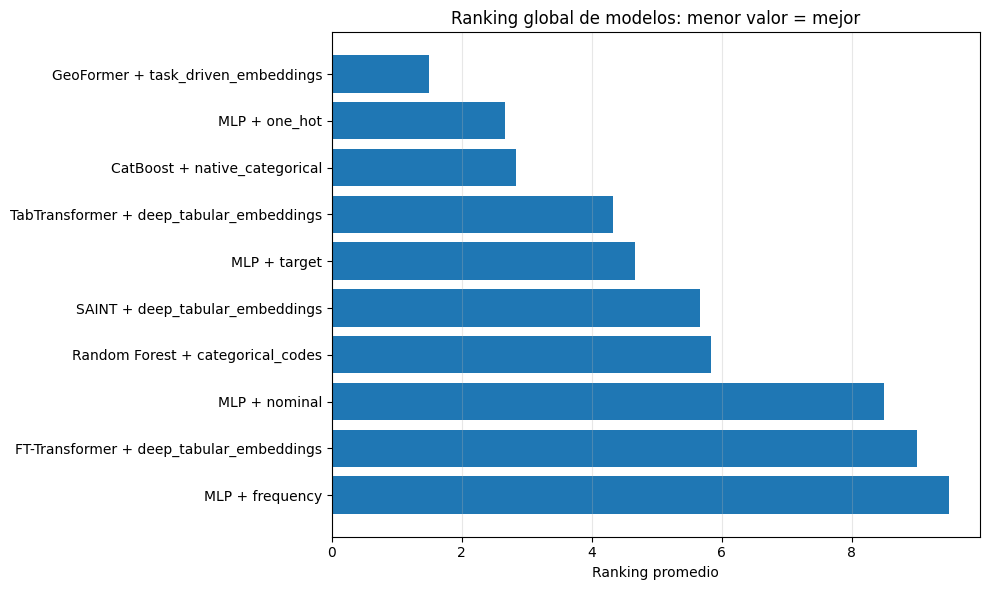

In [ ]:
ranking_clear_df = validation_metrics_df.copy()

ranking_clear_df["label"] = (
    ranking_clear_df["model"]
    + " + "
    + ranking_clear_df["encoding"]
)

ranking_clear_df["rank_AUC"] = ranking_clear_df["AUC"].rank(
    ascending=False,
    method="min"
)

ranking_clear_df["rank_AUPRC"] = ranking_clear_df["AUPRC"].rank(
    ascending=False,
    method="min"
)

ranking_clear_df["rank_F1"] = ranking_clear_df["F1"].rank(
    ascending=False,
    method="min"
)

ranking_clear_df["rank_MCC"] = ranking_clear_df["MCC"].rank(
    ascending=False,
    method="min"
)

ranking_clear_df["rank_Balanced_Accuracy"] = ranking_clear_df["Balanced_Accuracy"].rank(
    ascending=False,
    method="min"
)

ranking_clear_df["rank_Brier"] = ranking_clear_df["Brier"].rank(
    ascending=True,
    method="min"
)

ranking_cols = [
    "rank_AUC",
    "rank_AUPRC",
    "rank_F1",
    "rank_MCC",
    "rank_Balanced_Accuracy",
    "rank_Brier"
]

ranking_clear_df["mean_rank"] = ranking_clear_df[ranking_cols].mean(axis=1)

ranking_clear_df = ranking_clear_df.sort_values(
    "mean_rank",
    ascending=True
).reset_index(drop=True)

ranking_clear_df.to_excel(
    os.path.join(OUTPUT_ROOT, "overall_mean_rank_baseline_models.xlsx"),
    index=False
)

display(ranking_clear_df[[
    "model",
    "encoding",
    "AUC",
    "AUPRC",
    "F1",
    "MCC",
    "Balanced_Accuracy",
    "Brier",
    "mean_rank"
]].head(12))

plot_df = ranking_clear_df.head(12).copy()

plt.figure(figsize=(10, 6))
y_pos = np.arange(len(plot_df))

plt.barh(
    y_pos,
    plot_df["mean_rank"].values
)

plt.yticks(y_pos, plot_df["label"].values)
plt.xlabel("Ranking promedio")
plt.title("Ranking global de modelos: menor valor = mejor")
plt.gca().invert_yaxis()
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()

save_current_figure(
    os.path.join(OUTPUT_ROOT, "overall_mean_rank_top_12.png"),
    dpi=300
)

plt.show()

In [ ]:
pivot_metrics = ["AUC", "AUPRC", "F1", "MCC", "Balanced_Accuracy", "Brier"]

for metric in pivot_metrics:
    pivot = validation_metrics_df.pivot_table(
        index="model",
        columns="encoding",
        values=metric,
        aggfunc="mean"
    )

    pivot.to_excel(
        os.path.join(OUTPUT_ROOT, f"pivot_{metric}_by_model_encoding.xlsx")
    )

    display(pivot)

encoding,categorical_codes,deep_tabular_embeddings,frequency,native_categorical,nominal,one_hot,target,task_driven_embeddings
model,,,,,,,,
CatBoost,NaN,NaN,NaN,0.961782,NaN,NaN,NaN,NaN
FT-Transformer,NaN,0.924921,NaN,NaN,NaN,NaN,NaN,NaN
GeoFormer,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.966983
MLP,NaN,NaN,0.924469,NaN,0.925373,0.96427,0.957033,NaN
Random Forest,0.934419,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SAINT,NaN,0.937585,NaN,NaN,NaN,NaN,NaN,NaN
TabTransformer,NaN,0.952058,NaN,NaN,NaN,NaN,NaN,NaN


encoding,categorical_codes,deep_tabular_embeddings,frequency,native_categorical,nominal,one_hot,target,task_driven_embeddings
model,,,,,,,,
CatBoost,NaN,NaN,NaN,0.983056,NaN,NaN,NaN,NaN
FT-Transformer,NaN,0.957392,NaN,NaN,NaN,NaN,NaN,NaN
GeoFormer,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.986078
MLP,NaN,NaN,0.96574,NaN,0.96807,0.984696,0.981136,NaN
Random Forest,0.971038,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SAINT,NaN,0.973773,NaN,NaN,NaN,NaN,NaN,NaN
TabTransformer,NaN,0.979185,NaN,NaN,NaN,NaN,NaN,NaN


encoding,categorical_codes,deep_tabular_embeddings,frequency,native_categorical,nominal,one_hot,target,task_driven_embeddings
model,,,,,,,,
CatBoost,NaN,NaN,NaN,0.939394,NaN,NaN,NaN,NaN
FT-Transformer,NaN,0.910448,NaN,NaN,NaN,NaN,NaN,NaN
GeoFormer,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.938462
MLP,NaN,NaN,0.897059,NaN,0.899225,0.942857,0.925373,NaN
Random Forest,0.912,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SAINT,NaN,0.912000,NaN,NaN,NaN,NaN,NaN,NaN
TabTransformer,NaN,0.920635,NaN,NaN,NaN,NaN,NaN,NaN


encoding,categorical_codes,deep_tabular_embeddings,frequency,native_categorical,nominal,one_hot,target,task_driven_embeddings
model,,,,,,,,
CatBoost,NaN,NaN,NaN,0.822643,NaN,NaN,NaN,NaN
FT-Transformer,NaN,0.728630,NaN,NaN,NaN,NaN,NaN,NaN
GeoFormer,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.827678
MLP,NaN,NaN,0.679173,NaN,0.721187,0.818662,0.773858,NaN
Random Forest,0.781635,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SAINT,NaN,0.781635,NaN,NaN,NaN,NaN,NaN,NaN
TabTransformer,NaN,0.798646,NaN,NaN,NaN,NaN,NaN,NaN


encoding,categorical_codes,deep_tabular_embeddings,frequency,native_categorical,nominal,one_hot,target,task_driven_embeddings
model,,,,,,,,
CatBoost,NaN,NaN,NaN,0.917232,NaN,NaN,NaN,NaN
FT-Transformer,NaN,0.864315,NaN,NaN,NaN,NaN,NaN,NaN
GeoFormer,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.924921
MLP,NaN,NaN,0.834012,NaN,0.87223,0.886477,0.886929,NaN
Random Forest,0.910222,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SAINT,NaN,0.910222,NaN,NaN,NaN,NaN,NaN,NaN
TabTransformer,NaN,0.917684,NaN,NaN,NaN,NaN,NaN,NaN


encoding,categorical_codes,deep_tabular_embeddings,frequency,native_categorical,nominal,one_hot,target,task_driven_embeddings
model,,,,,,,,
CatBoost,NaN,NaN,NaN,0.081321,NaN,NaN,NaN,NaN
FT-Transformer,NaN,0.111784,NaN,NaN,NaN,NaN,NaN,NaN
GeoFormer,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.069586
MLP,NaN,NaN,0.107364,NaN,0.108803,0.067904,0.079053,NaN
Random Forest,0.097152,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SAINT,NaN,0.099106,NaN,NaN,NaN,NaN,NaN,NaN
TabTransformer,NaN,0.096085,NaN,NaN,NaN,NaN,NaN,NaN


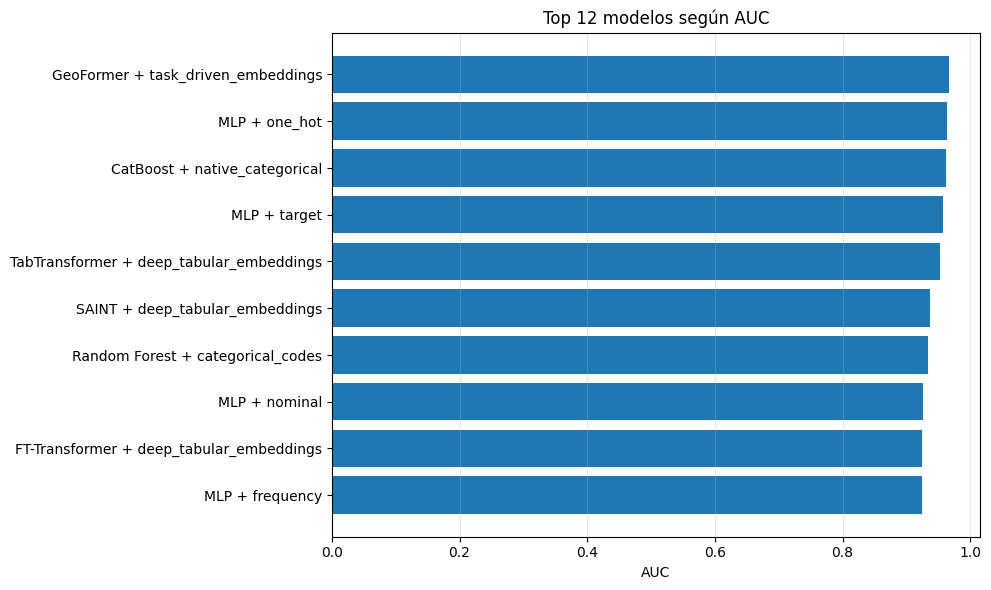

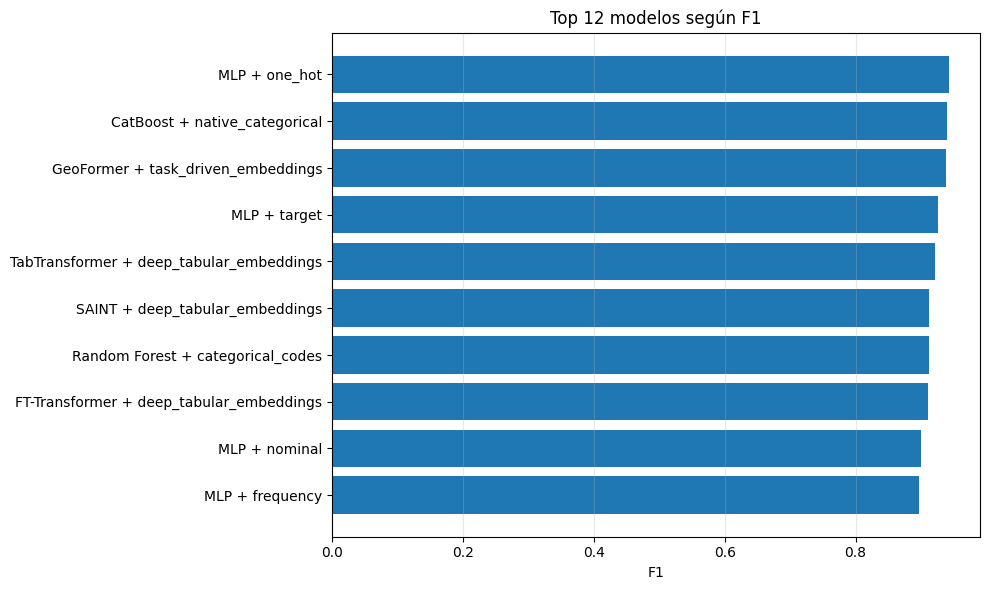

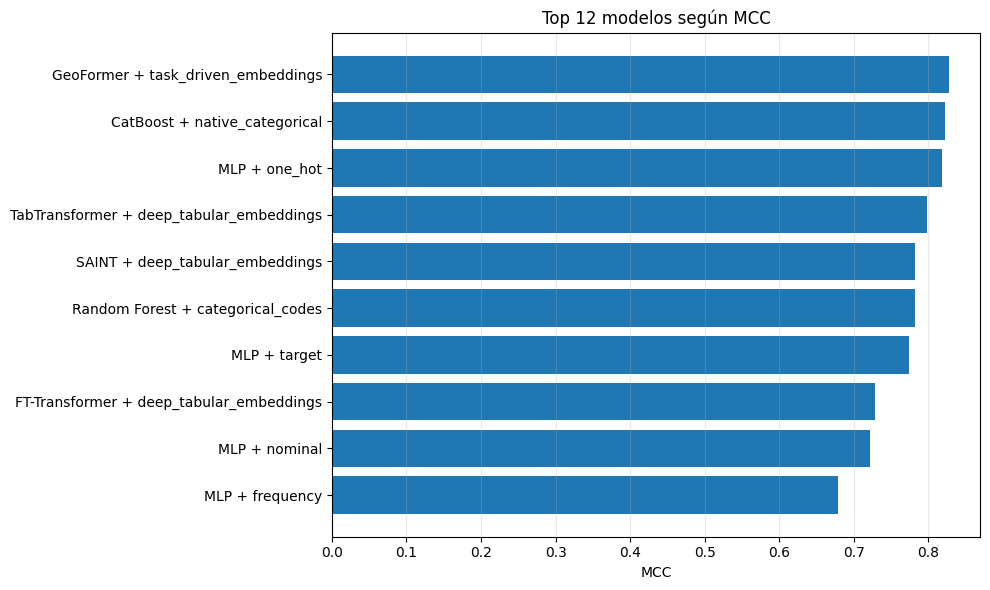

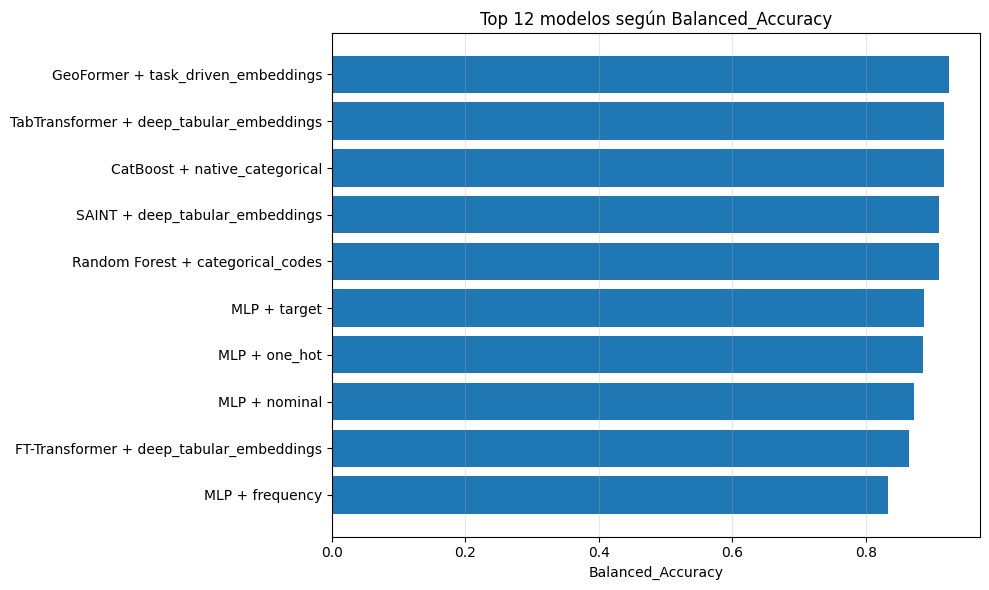

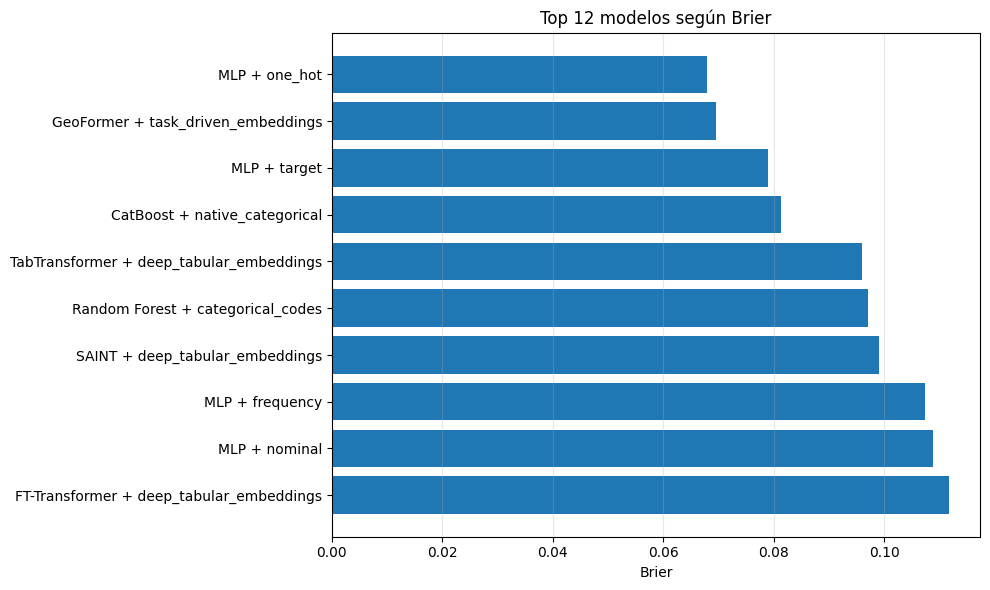

In [ ]:
def plot_top_metric(metric, top_n=12):
    plot_df = validation_metrics_df.copy()
    plot_df["label"] = plot_df["model"] + " + " + plot_df["encoding"]

    if metric == "Brier":
        plot_df = plot_df.sort_values(metric, ascending=True).head(top_n)
    else:
        plot_df = plot_df.sort_values(metric, ascending=False).head(top_n)

    plt.figure(figsize=(10, 6))
    y_pos = np.arange(len(plot_df))

    plt.barh(y_pos, plot_df[metric].values)
    plt.yticks(y_pos, plot_df["label"].values)
    plt.xlabel(metric)
    plt.title(f"Top {top_n} modelos según {metric}")
    plt.gca().invert_yaxis()
    plt.grid(axis="x", alpha=0.3)
    plt.tight_layout()

    save_current_figure(
        os.path.join(OUTPUT_ROOT, f"top_{top_n}_{metric}.png"),
        dpi=300
    )

    plt.show()


for metric in ["AUC", "F1", "MCC", "Balanced_Accuracy", "Brier"]:
    plot_top_metric(metric, top_n=12)

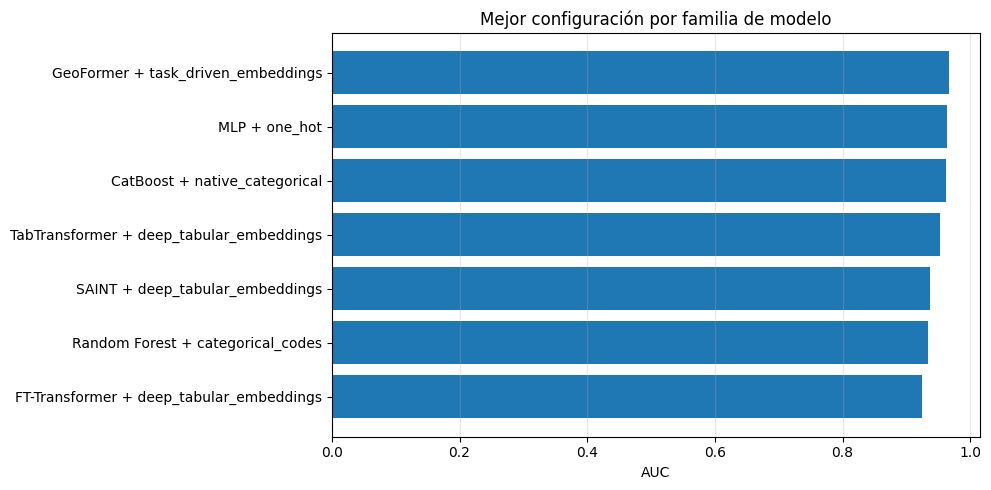

In [ ]:
# Mejor configuración de cada familia de modelos según AUC
family_df = validation_metrics_df.copy()

family_df["family"] = family_df["model"].replace({
    "Random Forest": "Random Forest",
    "CatBoost": "CatBoost",
    "MLP": "MLP",
    "GeoFormer": "GeoFormer",
    "TabTransformer": "TabTransformer",
    "FT-Transformer": "FT-Transformer",
    "SAINT": "SAINT"
})

family_df["label"] = family_df["model"] + " + " + family_df["encoding"]

best_by_family = (
    family_df
    .sort_values("AUC", ascending=False)
    .groupby("family", as_index=False)
    .head(1)
    .sort_values("AUC", ascending=False)
)

best_by_family.to_excel(
    os.path.join(OUTPUT_ROOT, "best_model_by_family_AUC.xlsx"),
    index=False
)

plt.figure(figsize=(10, 5))
y_pos = np.arange(len(best_by_family))

plt.barh(
    y_pos,
    best_by_family["AUC"].values
)

plt.yticks(y_pos, best_by_family["label"].values)
plt.xlabel("AUC")
plt.title("Mejor configuración por familia de modelo")
plt.gca().invert_yaxis()
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()

save_current_figure(
    os.path.join(OUTPUT_ROOT, "best_model_by_family_AUC.png"),
    dpi=300
)

plt.show()

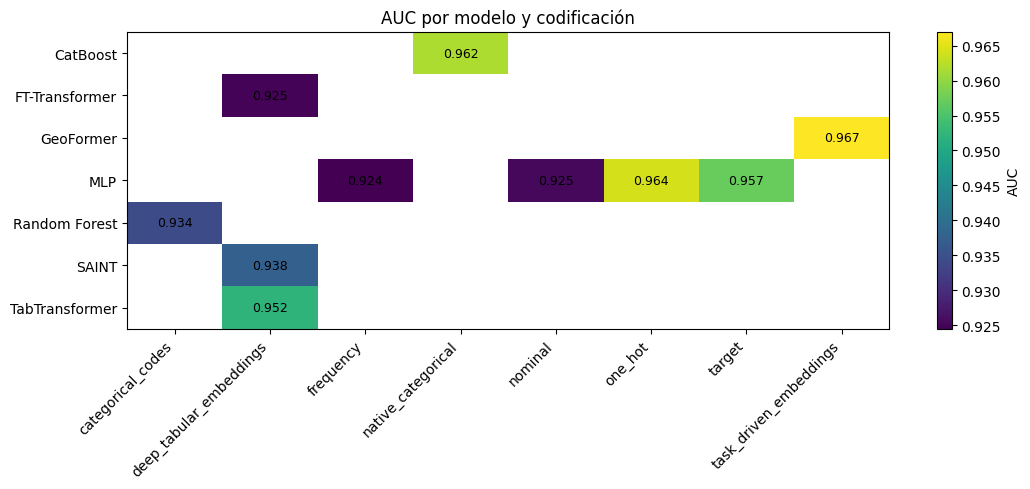

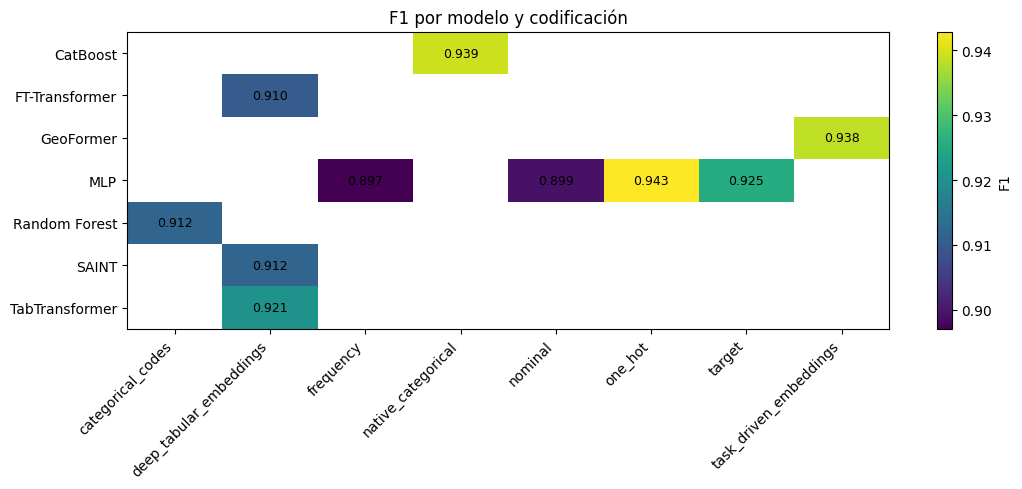

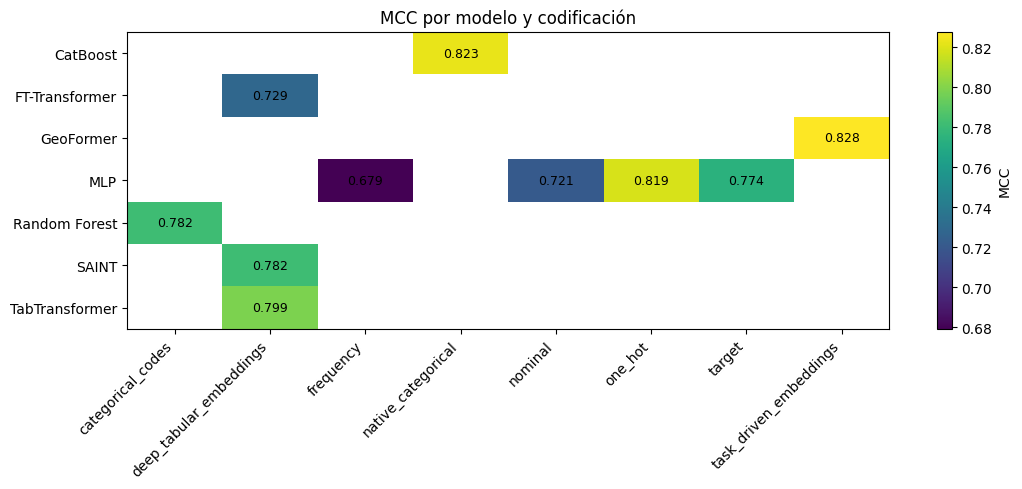

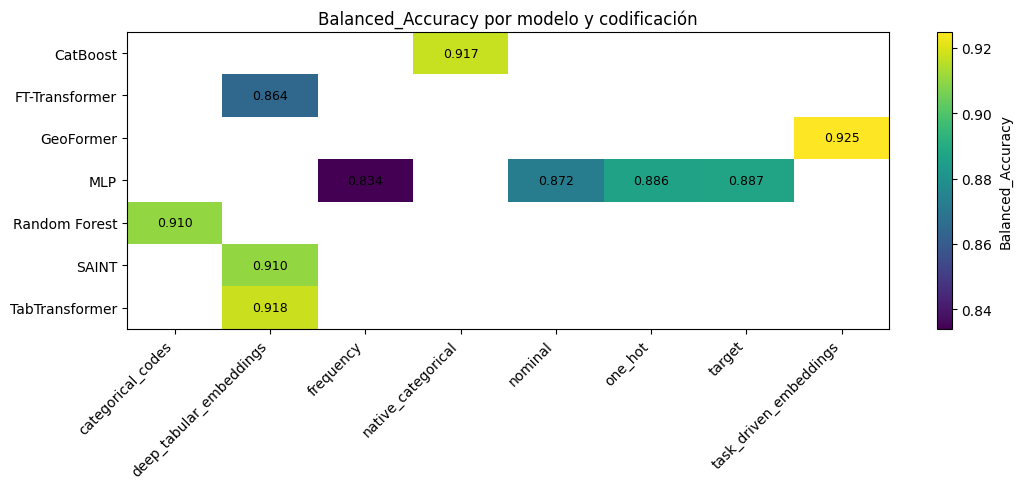

In [ ]:
def plot_heatmap_metric(metric):
    pivot = validation_metrics_df.pivot_table(
        index="model",
        columns="encoding",
        values=metric,
        aggfunc="mean"
    )

    values = pivot.values.astype(float)

    plt.figure(figsize=(11, 5))
    im = plt.imshow(values, aspect="auto")

    plt.colorbar(im, label=metric)
    plt.xticks(np.arange(len(pivot.columns)), pivot.columns, rotation=45, ha="right")
    plt.yticks(np.arange(len(pivot.index)), pivot.index)

    for i in range(values.shape[0]):
        for j in range(values.shape[1]):
            if not np.isnan(values[i, j]):
                plt.text(
                    j,
                    i,
                    f"{values[i, j]:.3f}",
                    ha="center",
                    va="center",
                    fontsize=9
                )

    plt.title(f"{metric} por modelo y codificación")
    plt.tight_layout()

    save_current_figure(
        os.path.join(OUTPUT_ROOT, f"heatmap_{metric}_model_encoding.png"),
        dpi=300
    )

    plt.show()


for metric in ["AUC", "F1", "MCC", "Balanced_Accuracy"]:
    plot_heatmap_metric(metric)

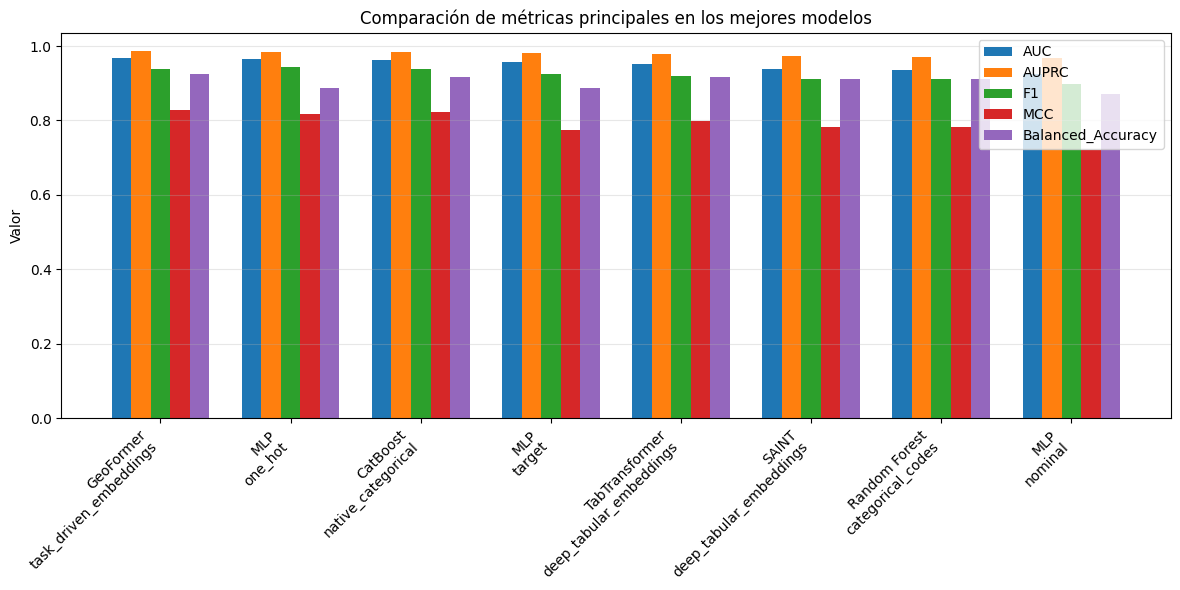

In [ ]:
# Comparación compacta de las métricas principales para los mejores 8 modelos según AUC
compact_metrics = ["AUC", "AUPRC", "F1", "MCC", "Balanced_Accuracy"]

top_df = validation_metrics_df.head(8).copy()
top_df["label"] = top_df["model"] + "\n" + top_df["encoding"]

x = np.arange(len(top_df))
width = 0.15

plt.figure(figsize=(12, 6))

for k, metric in enumerate(compact_metrics):
    plt.bar(
        x + (k - 2) * width,
        top_df[metric].values,
        width,
        label=metric
    )

plt.xticks(x, top_df["label"].values, rotation=45, ha="right")
plt.ylabel("Valor")
plt.title("Comparación de métricas principales en los mejores modelos")
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()

save_current_figure(
    os.path.join(OUTPUT_ROOT, "compact_top_models_metrics.png"),
    dpi=300
)

plt.show()

In [ ]:
best_row = validation_metrics_df.iloc[0]

print("Mejor configuración según AUC:")
display(best_row.to_frame().T)

best_model = best_row["model"]
best_encoding = best_row["encoding"]

if best_model == "GeoFormer":
    best_dir = os.path.join(OUTPUT_ROOT, "GeoFormer_task_driven_embeddings")

elif best_model == "CatBoost" and best_encoding == "native_categorical":
    best_dir = os.path.join(OUTPUT_ROOT, "CatBoost_native_categorical")

else:
    best_dir = os.path.join(
        OUTPUT_ROOT,
        f"{best_model.replace(' ', '_')}_{best_encoding}"
    )

print("Carpeta del mejor modelo:", best_dir)
print("Revisa su matriz de confusión en:", os.path.join(best_dir, "confusion_matrix_validation.png"))

Mejor configuración según AUC:


,model,encoding,split,best_threshold,train_time_seconds,n_features,TN,FP,FN,TP,...,Recall,F1,MCC,Balanced_Accuracy,Brier,n_trainable_parameters,early_stopping,best_epoch,best_val_loss,epochs_executed
0,GeoFormer,task_driven_embeddings,Validation,0.32,9.994652,8,31.0,2.0,6.0,61.0,...,0.910448,0.938462,0.827678,0.924921,0.069586,6213.0,True,29.0,0.142338,39.0


Carpeta del mejor modelo: GeoFormer_outputs_baseline_encoding_strategies/GeoFormer_task_driven_embeddings
Revisa su matriz de confusión en: GeoFormer_outputs_baseline_encoding_strategies/GeoFormer_task_driven_embeddings/confusion_matrix_validation.png


In [ ]:
best_auc = validation_metrics_df.iloc[0]
geoformer_row = validation_metrics_df[
    validation_metrics_df["model"] == "GeoFormer"
].iloc[0]

interpretation_rows = []

interpretation_rows.append({
    "punto": "Mejor modelo según AUC",
    "resultado": f"{best_auc['model']} + {best_auc['encoding']}",
    "valor": best_auc["AUC"]
})

interpretation_rows.append({
    "punto": "GeoFormer",
    "resultado": "GeoFormer + task_driven_embeddings",
    "valor": geoformer_row["AUC"]
})

interpretation_rows.append({
    "punto": "Diferencia AUC frente al mejor",
    "resultado": "GeoFormer - mejor modelo",
    "valor": geoformer_row["AUC"] - best_auc["AUC"]
})

interpretation_df = pd.DataFrame(interpretation_rows)

interpretation_df.to_excel(
    os.path.join(OUTPUT_ROOT, "automatic_interpretation_baseline_experiment.xlsx"),
    index=False
)

display(interpretation_df)

print("Lectura sugerida:")
print("- Si GeoFormer queda entre los mejores modelos, sus embeddings aprendidos son competitivos frente a codificaciones clásicas.")
print("- Si GeoFormer supera a modelos con nominal, one-hot, frequency o target encoding, se refuerza la hipótesis de que las relaciones entre variables categóricas aportan información.")
print("- Si un modelo clásico supera a GeoFormer, se debe discutir si el tamaño de muestra, el split o la complejidad del modelo favorecen a ese baseline.")

,punto,resultado,valor
0,Mejor modelo según AUC,GeoFormer + task_driven_embeddings,0.966983
1,GeoFormer,GeoFormer + task_driven_embeddings,0.966983
2,Diferencia AUC frente al mejor,GeoFormer - mejor modelo,0.000000


Lectura sugerida:
- Si GeoFormer queda entre los mejores modelos, sus embeddings aprendidos son competitivos frente a codificaciones clásicas.
- Si GeoFormer supera a modelos con nominal, one-hot, frequency o target encoding, se refuerza la hipótesis de que las relaciones entre variables categóricas aportan información.
- Si un modelo clásico supera a GeoFormer, se debe discutir si el tamaño de muestra, el split o la complejidad del modelo favorecen a ese baseline.


In [ ]:
ZIP_NAME = "GeoFormer_B_baseline_encoding_strategies_deep_tabular.zip"

if os.path.exists(ZIP_NAME):
    os.remove(ZIP_NAME)

shutil.make_archive(
    base_name=ZIP_NAME.replace(".zip", ""),
    format="zip",
    root_dir=OUTPUT_ROOT
)

print("ZIP creado:", ZIP_NAME)
print("Carpeta de resultados:", OUTPUT_ROOT)

# files.download(ZIP_NAME)

ZIP creado: GeoFormer_B_baseline_encoding_strategies_deep_tabular.zip
Carpeta de resultados: GeoFormer_outputs_baseline_encoding_strategies
